# Round 3 — Agent EDA

**Products:**
- Delta-1: `HYDROGEL_PACK`, `VELVETFRUIT_EXTRACT` (VEE)
- Options (European calls on VEE), position limit 300 each:
  `VEV_4000`, `VEV_4500`, `VEV_5000`, `VEV_5100`, `VEV_5200`, `VEV_5300`, `VEV_5400`, `VEV_5500`, `VEV_6000`, `VEV_6500`

**Days covered:** 0, 1, 2 (historical)
**TTE mapping:** day 0 → 8d, day 1 → 7d, day 2 → 6d. **Round-3 live trading begins at TTE = 5d.**

---
**Sections:**

A. Delta-1 analysis (reused from round 2)
 1. Setup & Data Loading
 2. Understanding Data
 3. Wall-Mid Features
 4. Price Overview
 5. Spread
 6. Order-Book Depth
 7. Trade Flow
 8. Fair-Value / Residual AC
 9. Cumulative PnL

B. Voucher (options) analysis (new in round 3)
 B1. Chain overview & liquidity
 B2. No-arbitrage sanity checks
 B3. Intrinsic vs. time value
 B4. Moneyness & empirical delta
 B5. Implied-volatility surface
 B6. Realized vs. implied vol
 B7. Correlation matrix
 B8. Delta-hedge simulation

C. Summary report & strategic recommendations

## A.1 Setup & Data Loading

In [37]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.optimize import brentq
from scipy.stats import norm

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

DATA_DIR = '../data'
DAYS = [0, 1, 2]
TTE_BY_DAY = {0: 8, 1: 7, 2: 6}  # historical TTE in calendar days

DELTA1 = ['HYDROGEL_PACK', 'VELVETFRUIT_EXTRACT']
UNDERLYING = 'VELVETFRUIT_EXTRACT'
STRIKES = [4000, 4500, 5000, 5100, 5200, 5300, 5400, 5500, 6000, 6500]
VOUCHERS = [f'VEV_{K}' for K in STRIKES]
VOUCHER_STRIKE = {f'VEV_{K}': K for K in STRIKES}

DAY_COLORS = {0: '#1f77b4', 1: '#ff7f0e', 2: '#2ca02c'}
PROD_COLORS = {'HYDROGEL_PACK': '#e377c2', 'VELVETFRUIT_EXTRACT': '#17becf'}

OUTPUT_DIR = os.path.join(DATA_DIR, '..', 'notebooks', 'output')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('Output dir:', os.path.abspath(OUTPUT_DIR))

Output dir: /home/jay/projects/competitions/imc-prosperity4/round3/notebooks/output


In [38]:
# ----- Load prices (all 3 days) -----
prices_frames = []
for day in DAYS:
    df = pd.read_csv(f'{DATA_DIR}/prices_round_3_day_{day}.csv', sep=';')
    prices_frames.append(df)
prices_all = pd.concat(prices_frames, ignore_index=True)

prices_all['time_index'] = prices_all['day'] * 1_000_000 + prices_all['timestamp']

vol_cols = [c for c in prices_all.columns if 'volume' in c]
prices_all[vol_cols] = prices_all[vol_cols].fillna(0)

# Drop rows with no mid (one-sided or empty book)
prices_all = prices_all[prices_all['mid_price'] > 0].copy()

# ----- Load trades -----
trades_frames = []
for day in DAYS:
    df = pd.read_csv(f'{DATA_DIR}/trades_round_3_day_{day}.csv', sep=';')
    df['day'] = day
    trades_frames.append(df)
trades_all = pd.concat(trades_frames, ignore_index=True)
trades_all['time_index'] = trades_all['day'] * 1_000_000 + trades_all['timestamp']

print(f'Prices rows: {len(prices_all):,}')
print(f'  Products : {sorted(prices_all["product"].unique().tolist())}')
print(f'  Days     : {sorted(prices_all["day"].unique().tolist())}')
print(f'Trades rows: {len(trades_all):,}')
print(f'  Symbols : {sorted(trades_all["symbol"].unique().tolist())}')
prices_all.head(3)

Prices rows: 360,000
  Products : ['HYDROGEL_PACK', 'VELVETFRUIT_EXTRACT', 'VEV_4000', 'VEV_4500', 'VEV_5000', 'VEV_5100', 'VEV_5200', 'VEV_5300', 'VEV_5400', 'VEV_5500', 'VEV_6000', 'VEV_6500']
  Days     : [0, 1, 2]
Trades rows: 4,048
  Symbols : ['HYDROGEL_PACK', 'VELVETFRUIT_EXTRACT', 'VEV_4000', 'VEV_4500', 'VEV_5000', 'VEV_5100', 'VEV_5200', 'VEV_5300', 'VEV_5400', 'VEV_5500', 'VEV_6000', 'VEV_6500']


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,time_index
0,0,0,VEV_5400,22,25,NaN,0.0,NaN,0.0,24,25,NaN,0.0,NaN,0.0,23.0,0.0,0
1,0,0,VEV_6500,0,16,NaN,0.0,NaN,0.0,1,16,NaN,0.0,NaN,0.0,0.5,0.0,0
2,0,0,VEV_5500,8,25,NaN,0.0,NaN,0.0,9,25,NaN,0.0,NaN,0.0,8.5,0.0,0


## A.2 Understanding Data

Sanity check: when an L1/L2/L3 volume slot is 0, is the corresponding price NaN?

In [39]:
volume_cols = [col for col in prices_all.columns if 'volume' in col and 'mid' not in col]
price_cols  = [col for col in prices_all.columns if 'price'  in col and 'mid' not in col]
vol_price_pair = list(zip(price_cols, volume_cols))

mask = pd.concat(
    [prices_all[price].notna() & (prices_all[volume] == 0.0) for price, volume in vol_price_pair],
    axis=1
).any(axis=1)
print(f'Rows with vol=0 but price!=NaN: {int(mask.sum())}')
# Expected: 0 — same invariant as round 1/2.

Rows with vol=0 but price!=NaN: 0


## A.3 Wall-Mid Feature

"Best" bid/ask across L1→L3 = first non-NaN level. "Wall" bid/ask = the price level with the largest volume. These are more robust references than the raw L1 mid on wide-spread ticks.

In [40]:
def compute_wall_mid(row):
    bids = [(row['bid_price_1'], row['bid_volume_1']),
            (row['bid_price_2'], row['bid_volume_2']),
            (row['bid_price_3'], row['bid_volume_3'])]
    asks = [(row['ask_price_1'], row['ask_volume_1']),
            (row['ask_price_2'], row['ask_volume_2']),
            (row['ask_price_3'], row['ask_volume_3'])]
    valid_bids = [(p, v) for p, v in bids if pd.notna(p) and v > 0]
    valid_asks = [(p, v) for p, v in asks if pd.notna(p) and v > 0]
    if not valid_bids or not valid_asks:
        return np.nan
    wall_bid = max(valid_bids, key=lambda x: x[1])[0]
    wall_ask = max(valid_asks, key=lambda x: x[1])[0]
    return (wall_bid + wall_ask) / 2

prices_all['wall_mid'] = prices_all.apply(compute_wall_mid, axis=1)
prices_all['wall_mid'] = prices_all['wall_mid'].fillna(prices_all['mid_price'])
prices_all[['product', 'timestamp', 'mid_price', 'wall_mid']].head()

,product,timestamp,mid_price,wall_mid
0,VEV_5400,0,23.0,23.0
1,VEV_6500,0,0.5,0.5
2,VEV_5500,0,8.5,8.5
3,VEV_5200,0,101.5,102.0
4,VEV_5300,0,53.0,52.5


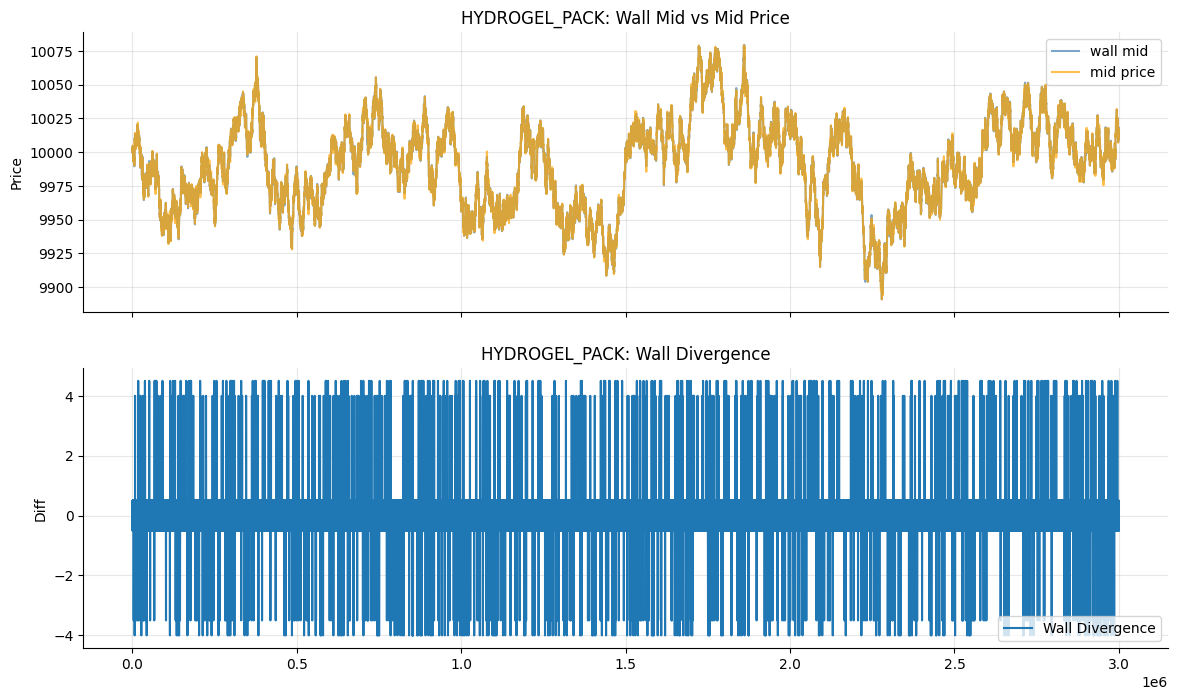

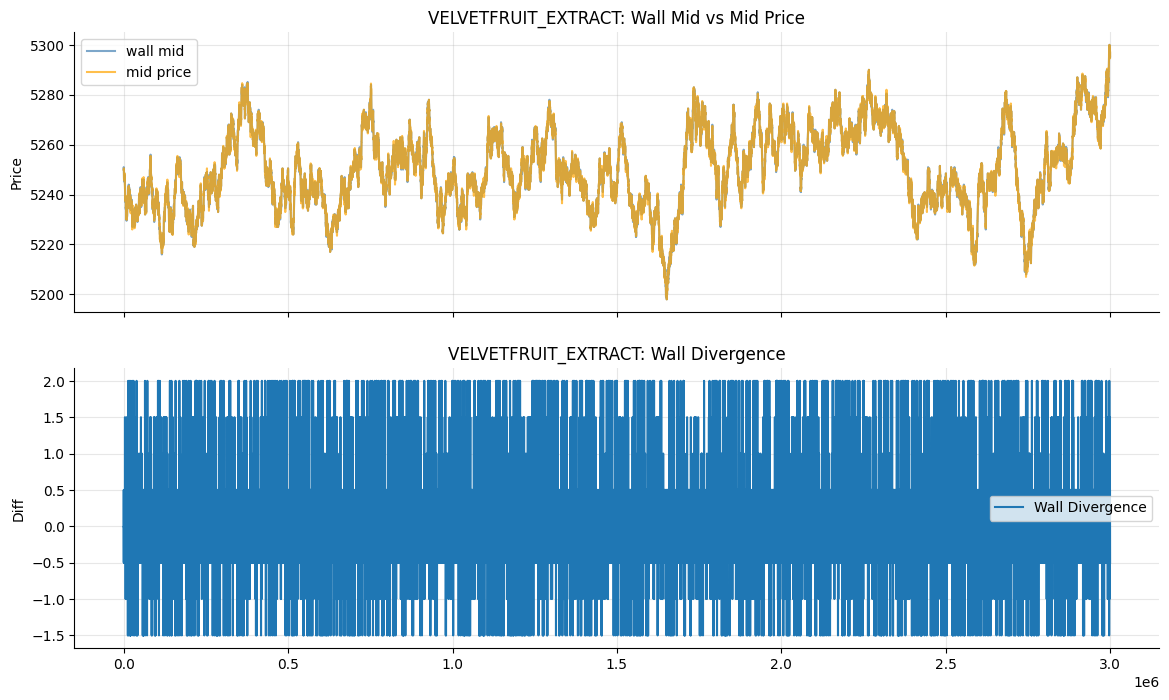

In [41]:
# Wall mid vs mid, for delta-1 products
for prod in DELTA1:
    p = prices_all[prices_all['product'] == prod].copy()
    p['wall_div'] = p['wall_mid'] - p['mid_price']

    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    axes[0].plot(p['time_index'], p['wall_mid'], label='wall mid', alpha=0.7, color='steelblue')
    axes[0].plot(p['time_index'], p['mid_price'], label='mid price', alpha=0.7, color='orange')
    axes[0].set_title(f'{prod}: Wall Mid vs Mid Price'); axes[0].set_ylabel('Price'); axes[0].legend()

    axes[1].plot(p['time_index'], p['wall_div'], label='Wall Divergence')
    axes[1].set_title(f'{prod}: Wall Divergence'); axes[1].set_ylabel('Diff'); axes[1].legend()
    fig.savefig(f'{OUTPUT_DIR}/eda_wallmid_{prod}.png', dpi=150, bbox_inches='tight')
    plt.show()

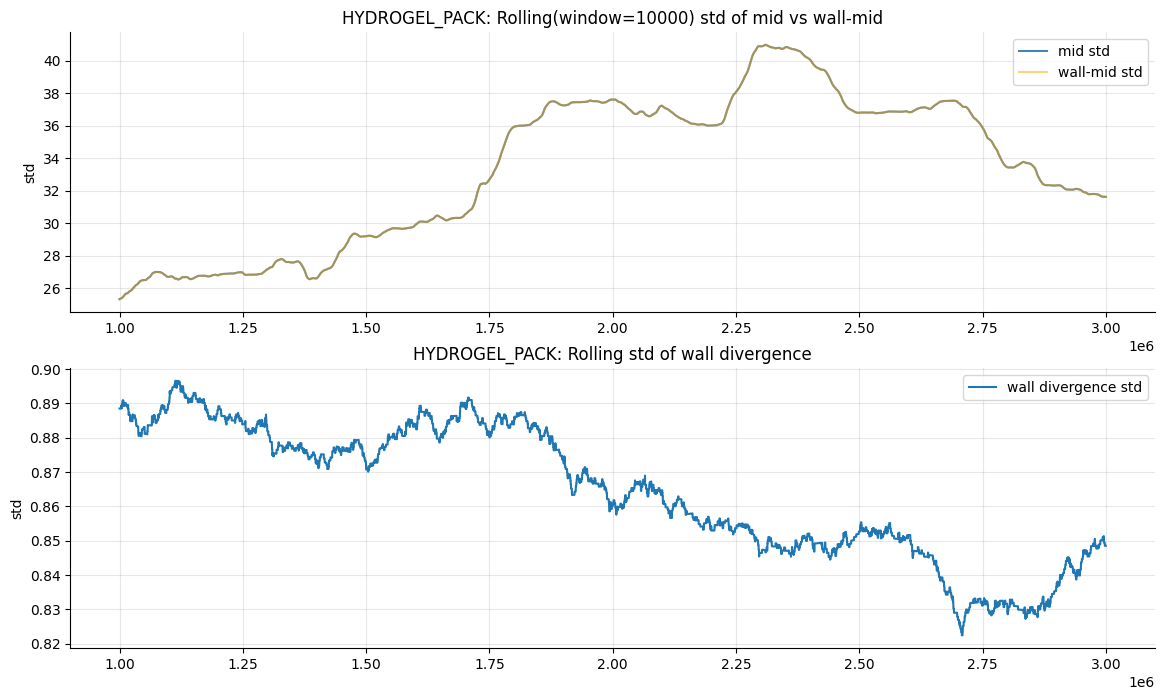

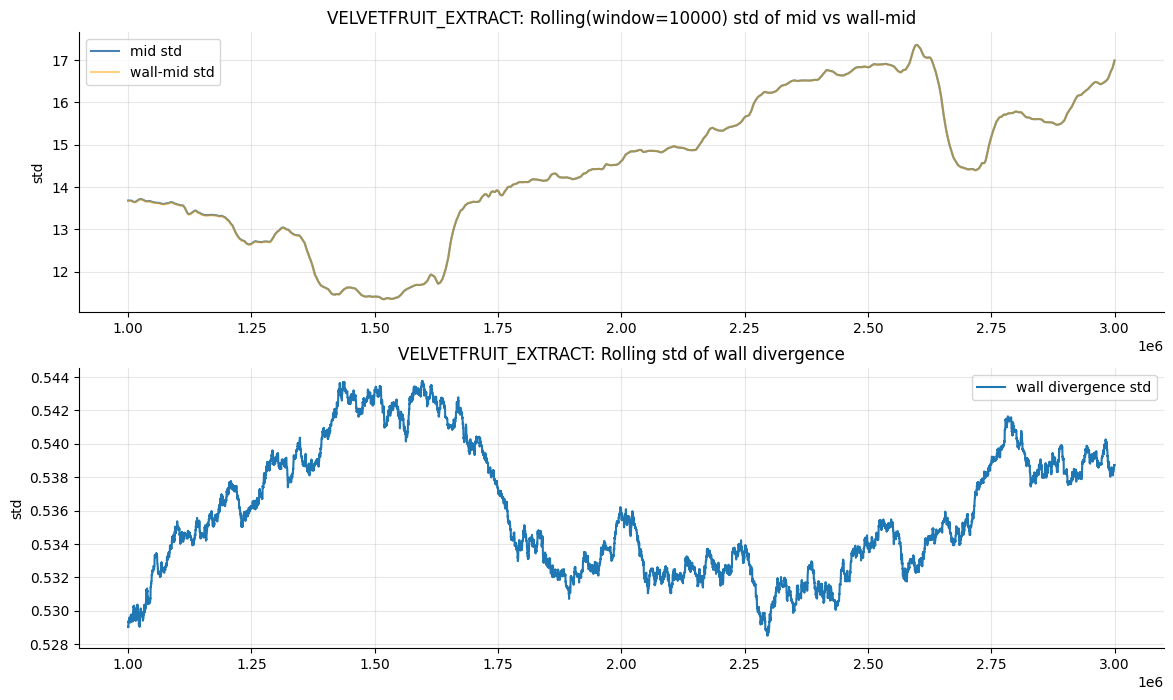

In [42]:
# Rolling std comparison
rolling_std_window = 10000
for prod in DELTA1:
    p = prices_all[prices_all['product'] == prod].copy().sort_values('time_index')
    p['wall_div'] = p['wall_mid'] - p['mid_price']
    p['rolling_std_wall'] = p['wall_mid'].rolling(rolling_std_window, closed='right').std()
    p['rolling_std_mid']  = p['mid_price'].rolling(rolling_std_window, closed='right').std()
    p['rolling_std_div']  = p['wall_div'].rolling(rolling_std_window, closed='right').std()

    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    axes[0].plot(p['time_index'], p['rolling_std_mid'], label='mid std', color='steelblue')
    axes[0].plot(p['time_index'], p['rolling_std_wall'], label='wall-mid std', color='orange', alpha = 0.5)
    axes[0].set_title(f'{prod}: Rolling(window={rolling_std_window}) std of mid vs wall-mid')
    axes[0].set_ylabel('std'); axes[0].legend()

    axes[1].plot(p['time_index'], p['rolling_std_div'], label='wall divergence std')
    axes[1].set_title(f'{prod}: Rolling std of wall divergence')
    axes[1].set_ylabel('std'); axes[1].legend()
    fig.savefig(f'{OUTPUT_DIR}/eda_rolling_std_{prod}.png', dpi=150, bbox_inches='tight')
    plt.show()

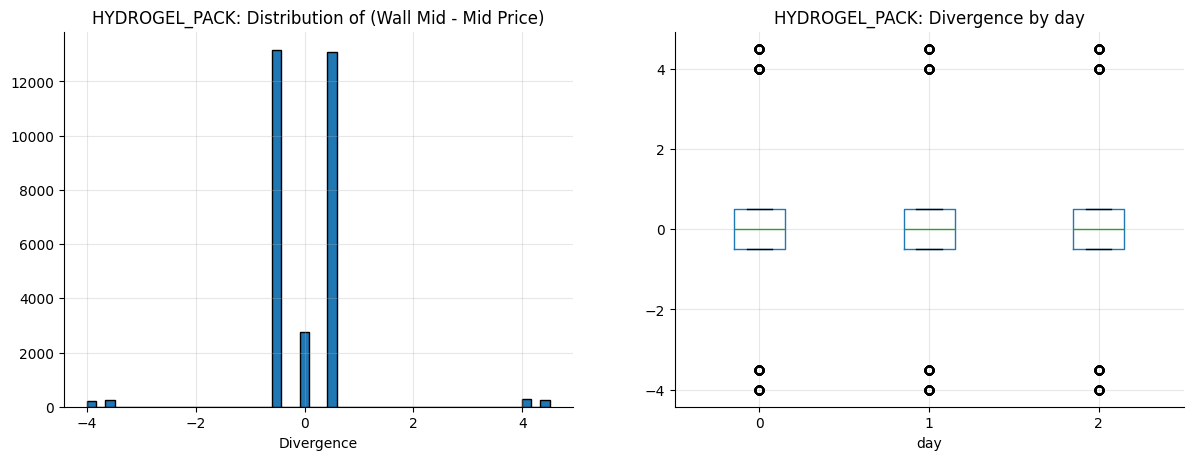

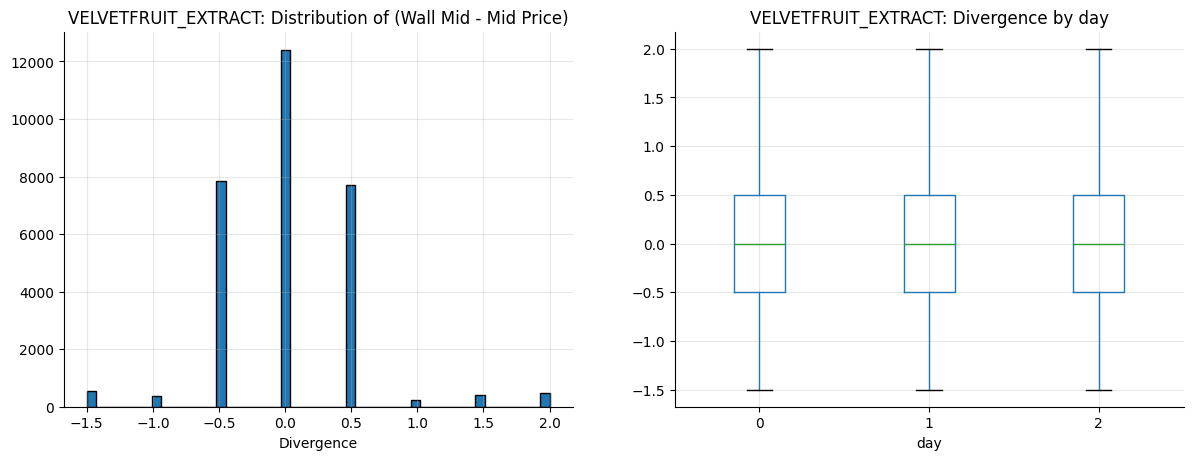

In [43]:
# Distribution of wall divergence
for prod in DELTA1:
    p = prices_all[prices_all['product'] == prod].copy()
    p['wall_div'] = p['wall_mid'] - p['mid_price']
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].hist(p['wall_div'].dropna(), bins=50, edgecolor='black')
    axes[0].set_title(f'{prod}: Distribution of (Wall Mid - Mid Price)')
    axes[0].set_xlabel('Divergence')
    p.boxplot(column='wall_div', by='day', ax=axes[1])
    axes[1].set_title(f'{prod}: Divergence by day')
    fig.suptitle('')
    fig.savefig(f'{OUTPUT_DIR}/eda_div_dist_{prod}.png', dpi=150, bbox_inches='tight')
    plt.show()

## A.4 Price Overview (delta-1 products)

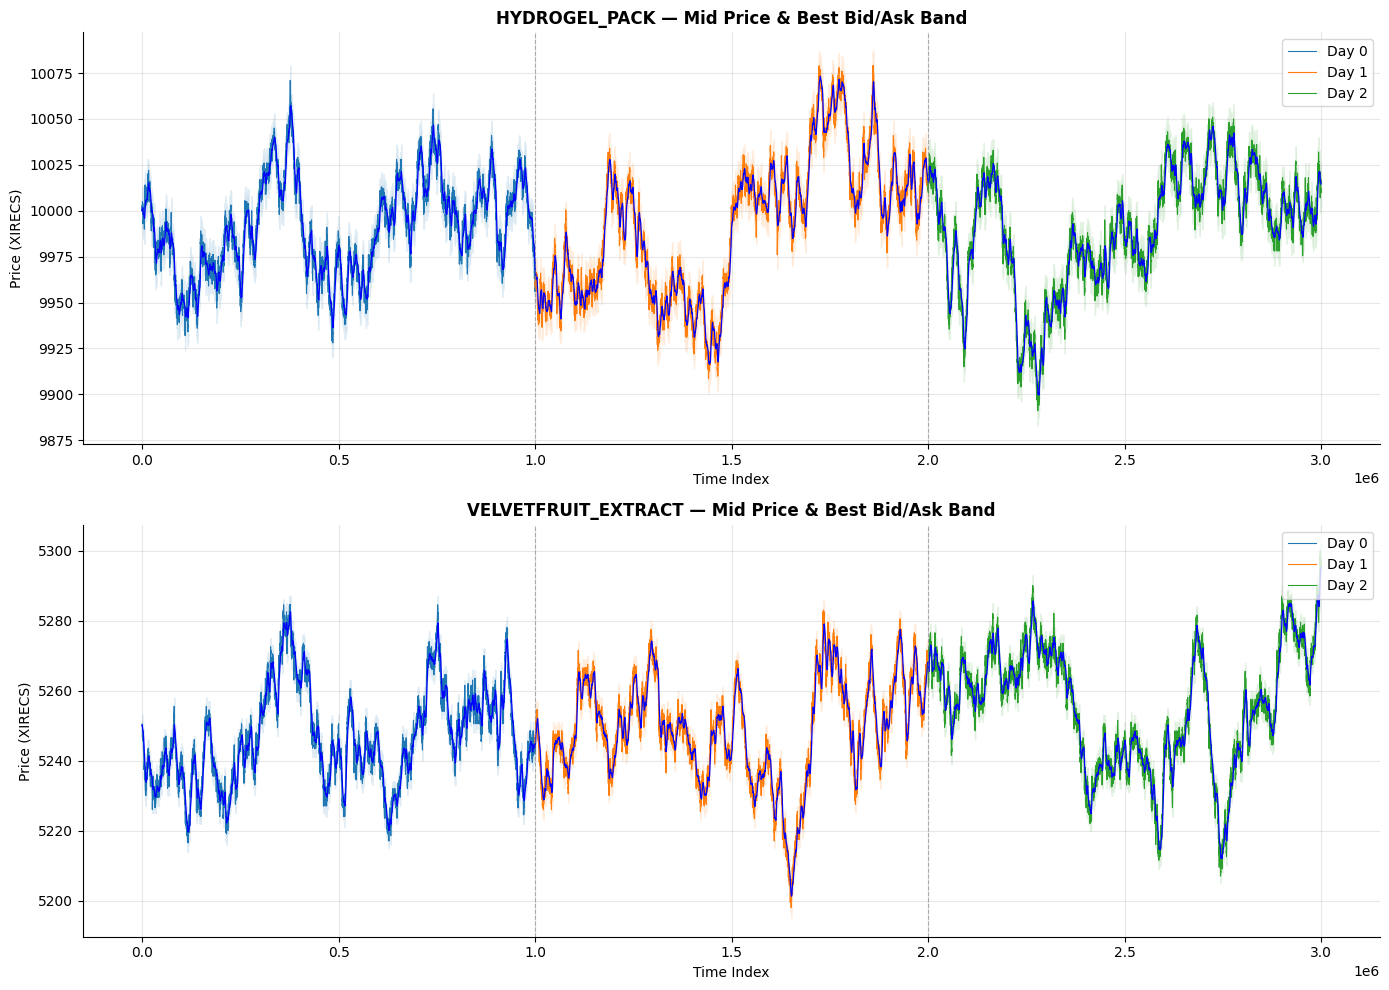

In [44]:
EMA_ALPHA = 0.05

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
for ax, product in zip(axes, DELTA1):
    p = prices_all[prices_all['product'] == product].copy().sort_values('time_index').reset_index(drop=True)
    p['ema'] = p['mid_price'].ewm(alpha=EMA_ALPHA, adjust=False).mean()

    for day in DAYS:
        d = p[p['day'] == day]
        ax.fill_between(d['time_index'], d['bid_price_1'], d['ask_price_1'],
                        alpha=0.12, color=DAY_COLORS[day])
        ax.plot(d['time_index'], d['mid_price'],
                color=DAY_COLORS[day], linewidth=0.8, label=f'Day {day}')
        ax.plot(d['time_index'], d['ema'], color='blue', linewidth=0.9)

    for bday in [1, 2]:
        ax.axvline(bday * 1_000_000, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.set_title(f'{product} — Mid Price & Best Bid/Ask Band', fontsize=12, fontweight='bold')
    ax.set_xlabel('Time Index')
    ax.set_ylabel('Price (XIRECS)')
    ax.legend(loc='upper right')

plt.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/eda_price_overview.png', dpi=150, bbox_inches='tight')
plt.show()

In [45]:
# Price statistics table
header = f"{'Product':<25} {'Min':>8} {'Max':>8} {'Mean':>9} {'Std':>7} {'CV':>9}"
sep = '─' * 68
lines = [header, sep]
print(header); print(sep)
for product in DELTA1:
    mp = prices_all[prices_all['product'] == product]['mid_price']
    cv = mp.std() / mp.mean()
    line = f"{product:<25} {mp.min():>8.1f} {mp.max():>8.1f} {mp.mean():>9.2f} {mp.std():>7.2f} {cv:>9.5f}"
    print(line); lines.append(line)
with open(f'{OUTPUT_DIR}/eda_price_stats.txt', 'w') as f:
    f.write('\n'.join(lines) + '\n')

Product                        Min      Max      Mean     Std        CV
────────────────────────────────────────────────────────────────────
HYDROGEL_PACK               9891.0  10079.0   9990.81   31.94   0.00320
VELVETFRUIT_EXTRACT         5198.0   5300.0   5250.10   15.63   0.00298


## A.5 Spread Analysis

A tight 1-tick spread is the market-making signature. Wide spreads indicate low liquidity or illiquid regimes.

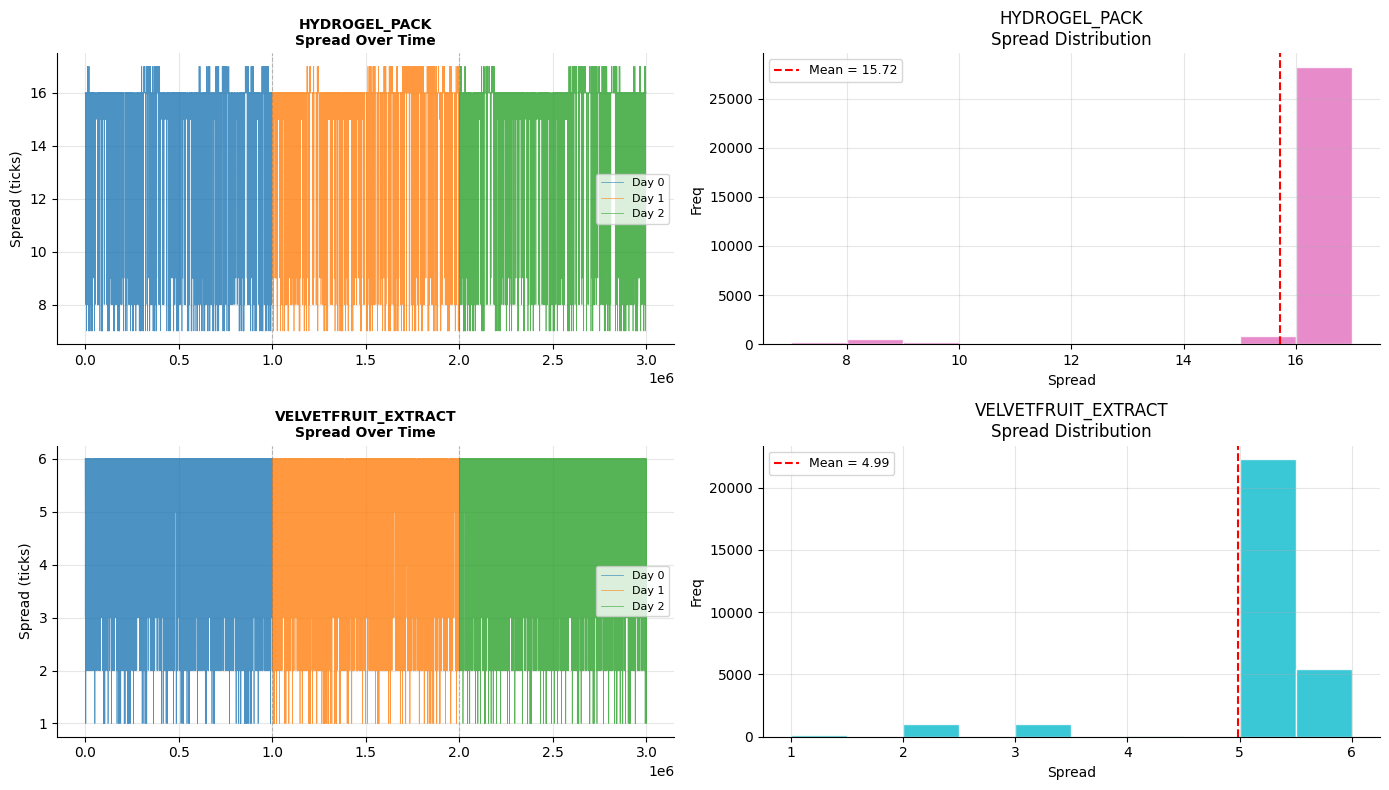

Product                       Mean    %==1    %==2    Max
────────────────────────────────────────────────────────────
HYDROGEL_PACK               15.721    0.0%    0.0%     17
VELVETFRUIT_EXTRACT          4.988    0.6%    3.4%      6


In [46]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for row, product in enumerate(DELTA1):
    p = prices_all[prices_all['product'] == product].copy()
    p['spread'] = p['ask_price_1'] - p['bid_price_1']
    p_spread = p.dropna(subset=['spread'])

    ax = axes[row, 0]
    for day in DAYS:
        d = p_spread[p_spread['day'] == day]
        ax.plot(d['time_index'], d['spread'], color=DAY_COLORS[day],
                linewidth=0.5, alpha=0.8, label=f'Day {day}')
    for bday in [1, 2]:
        ax.axvline(bday * 1_000_000, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.set_title(f'{product}\nSpread Over Time', fontsize=10, fontweight='bold')
    ax.set_ylabel('Spread (ticks)'); ax.legend(fontsize=8)

    ax = axes[row, 1]
    spread_vals = p_spread['spread']
    ax.hist(spread_vals, bins=max(int(spread_vals.nunique()), 10),
            edgecolor='white', color=PROD_COLORS[product], alpha=0.85)
    ax.axvline(spread_vals.mean(), color='red', linestyle='--', linewidth=1.5,
               label=f'Mean = {spread_vals.mean():.2f}')
    ax.set_title(f'{product}\nSpread Distribution'); ax.set_xlabel('Spread'); ax.set_ylabel('Freq'); ax.legend(fontsize=9)

plt.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/eda_spread.png', dpi=150, bbox_inches='tight')
plt.show()

# Spread summary
lines = []
header = f"{'Product':<25} {'Mean':>8} {'%==1':>7} {'%==2':>7} {'Max':>6}"
sep = '─' * 60
lines.extend([header, sep])
print(header); print(sep)
for product in DELTA1:
    p = prices_all[prices_all['product'] == product].copy()
    s = (p['ask_price_1'] - p['bid_price_1']).dropna()
    line = f"{product:<25} {s.mean():>8.3f} {(s==1).mean()*100:>6.1f}% {(s==2).mean()*100:>6.1f}% {s.max():>6.0f}"
    print(line); lines.append(line)
with open(f'{OUTPUT_DIR}/eda_spread_stats.txt', 'w') as f:
    f.write('\n'.join(lines) + '\n')

## A.6 Order-Book Depth & Imbalance

`imbalance = (bid_depth − ask_depth) / (bid_depth + ask_depth)` across L1+L2+L3. Positive = buy pressure.

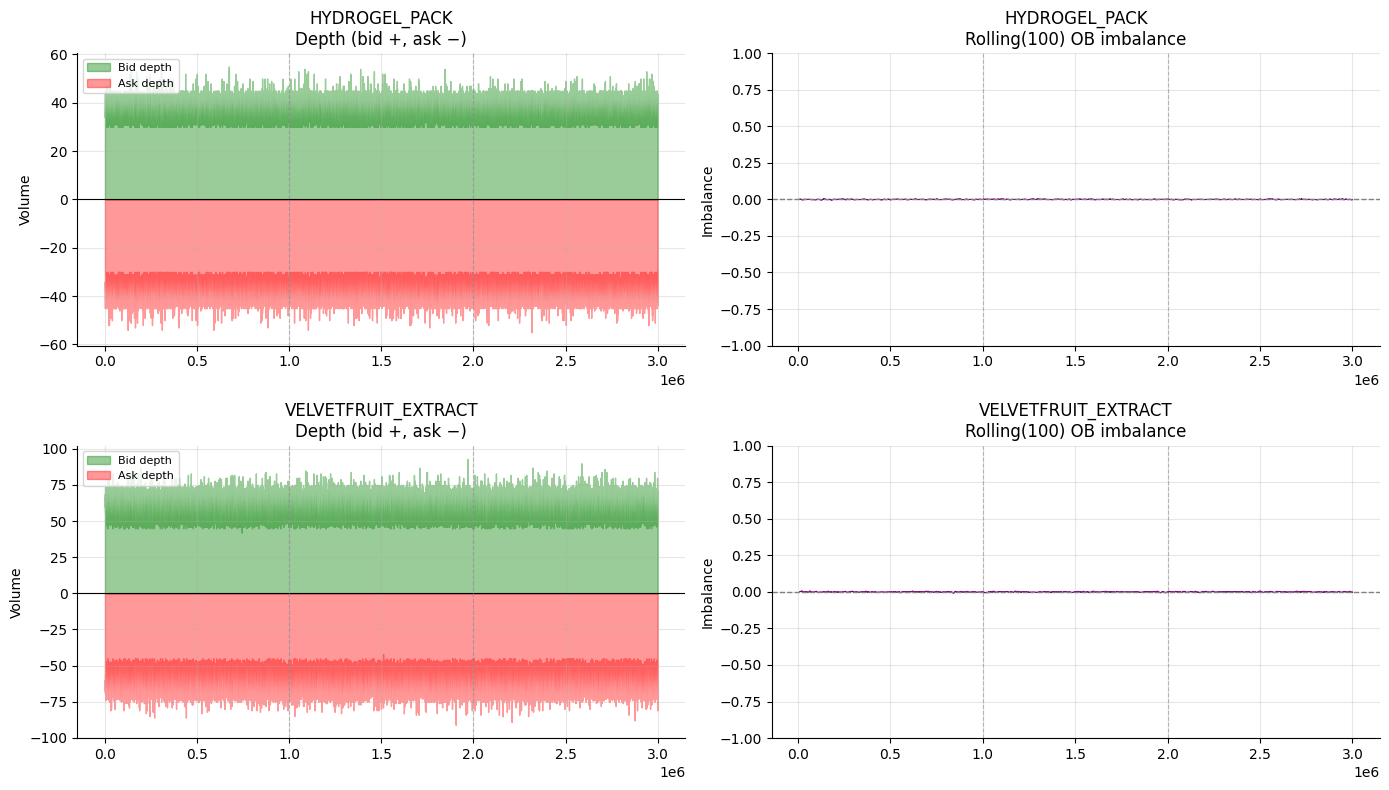

Product                      Avg Bid    Avg Ask    Avg Imb
────────────────────────────────────────────────────────────
HYDROGEL_PACK                   37.6       37.6    -0.0001
VELVETFRUIT_EXTRACT             60.4       60.4    -0.0000


In [47]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for row, product in enumerate(DELTA1):
    p = prices_all[prices_all['product'] == product].copy()
    p['bid_depth'] = p[['bid_volume_1', 'bid_volume_2', 'bid_volume_3']].sum(axis=1)
    p['ask_depth'] = p[['ask_volume_1', 'ask_volume_2', 'ask_volume_3']].sum(axis=1)
    total = p['bid_depth'] + p['ask_depth']
    p['imbalance'] = np.where(total > 0, (p['bid_depth'] - p['ask_depth']) / total, np.nan)

    ax = axes[row, 0]
    ax.fill_between(p['time_index'], 0, p['bid_depth'], alpha=0.4, color='green', label='Bid depth')
    ax.fill_between(p['time_index'], 0, -p['ask_depth'], alpha=0.4, color='red', label='Ask depth')
    ax.axhline(0, color='black', linewidth=0.8)
    for bday in [1, 2]: ax.axvline(bday * 1_000_000, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.set_title(f'{product}\nDepth (bid +, ask −)'); ax.set_ylabel('Volume'); ax.legend(fontsize=8)

    ax = axes[row, 1]
    rolling_imb = p.set_index('time_index')['imbalance'].rolling(100).mean()
    ax.plot(rolling_imb.index, rolling_imb.values, color='purple', linewidth=0.8)
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    for bday in [1, 2]: ax.axvline(bday * 1_000_000, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.set_title(f'{product}\nRolling(100) OB imbalance'); ax.set_ylabel('Imbalance'); ax.set_ylim(-1, 1)

plt.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/eda_ob_depth.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary
lines = []
header = f"{'Product':<25} {'Avg Bid':>10} {'Avg Ask':>10} {'Avg Imb':>10}"
sep = '─' * 60
lines.extend([header, sep]); print(header); print(sep)
for product in DELTA1:
    p = prices_all[prices_all['product'] == product].copy()
    bd = p[['bid_volume_1','bid_volume_2','bid_volume_3']].sum(axis=1)
    ad = p[['ask_volume_1','ask_volume_2','ask_volume_3']].sum(axis=1)
    tot = bd + ad
    imb = np.where(tot > 0, (bd - ad) / tot, np.nan)
    line = f"{product:<25} {bd.mean():>10.1f} {ad.mean():>10.1f} {np.nanmean(imb):>10.4f}"
    print(line); lines.append(line)
with open(f'{OUTPUT_DIR}/eda_ob_depth_stats.txt', 'w') as f:
    f.write('\n'.join(lines) + '\n')

## A.7 Trade Flow (delta-1 products)

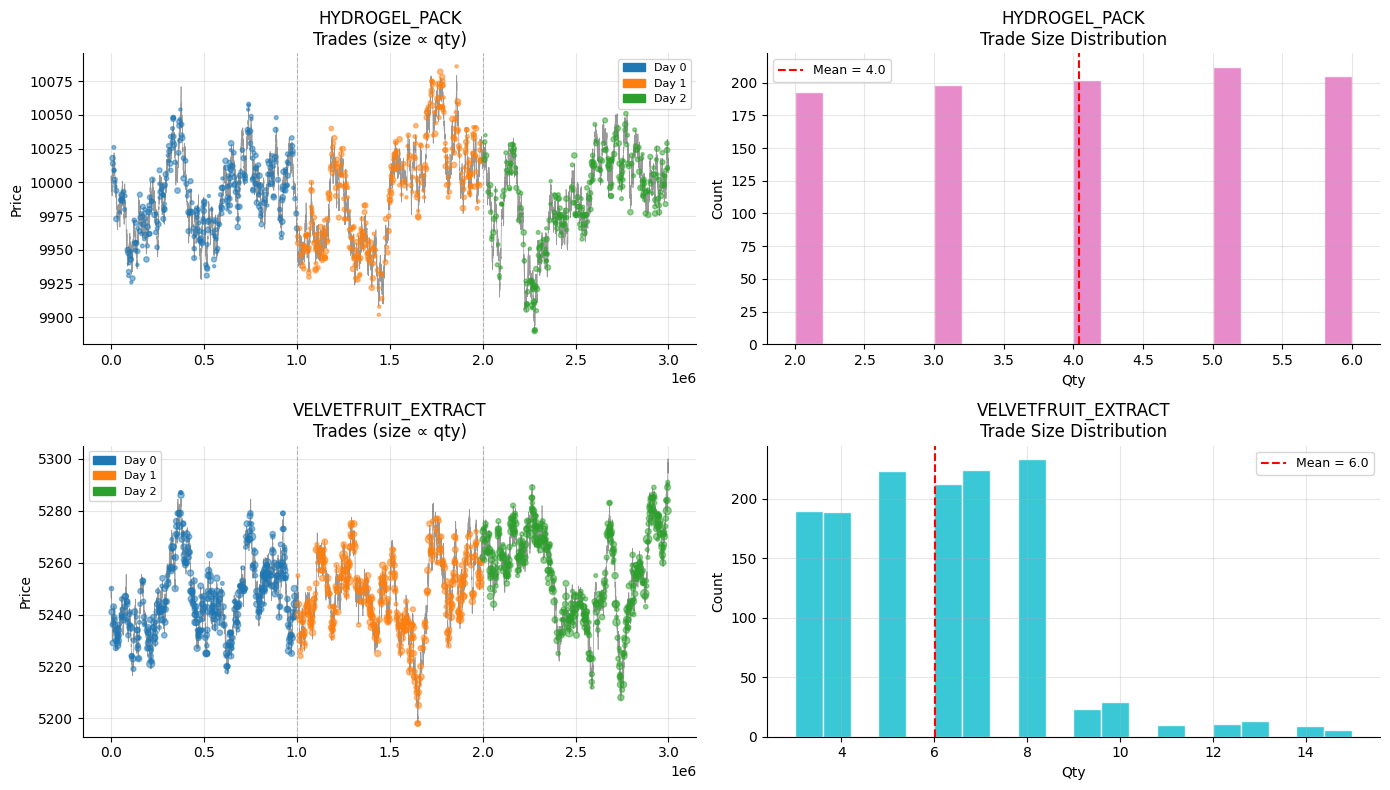

In [48]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for row, product in enumerate(DELTA1):
    t = trades_all[trades_all['symbol'] == product].copy()
    p = prices_all[prices_all['product'] == product]

    ax = axes[row, 0]
    colors = [DAY_COLORS[d] for d in t['day']]
    ax.scatter(t['time_index'], t['price'], s=t['quantity'] * 2.5,
               c=colors, alpha=0.5, zorder=3, label='Trade')
    ax.plot(p['time_index'], p['mid_price'], color='black', linewidth=0.5, alpha=0.4, label='mid')
    for bday in [1, 2]: ax.axvline(bday * 1_000_000, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    handles = [mpatches.Patch(color=DAY_COLORS[d], label=f'Day {d}') for d in DAYS]
    ax.legend(handles=handles, fontsize=8)
    ax.set_title(f'{product}\nTrades (size ∝ qty)'); ax.set_ylabel('Price')

    ax = axes[row, 1]
    if len(t) > 0:
        ax.hist(t['quantity'], bins=20, edgecolor='white', color=PROD_COLORS[product], alpha=0.85)
        ax.axvline(t['quantity'].mean(), color='red', linestyle='--', linewidth=1.5,
                   label=f"Mean = {t['quantity'].mean():.1f}")
        ax.legend(fontsize=9)
    ax.set_title(f'{product}\nTrade Size Distribution'); ax.set_xlabel('Qty'); ax.set_ylabel('Count')

plt.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/eda_trade_flow.png', dpi=150, bbox_inches='tight')
plt.show()

In [49]:
# VWAP vs Mean Mid per day
lines = ['VWAP vs Mean Mid-Price by Day']
header = f"{'Product':<25} {'Day':>4} {'VWAP':>10} {'MeanMid':>10} {'Diff':>8} {'#Trades':>9}"
sep = '─' * 70
lines.extend([header, sep]); print(header); print(sep)
for product in DELTA1:
    t = trades_all[trades_all['symbol'] == product]
    p = prices_all[prices_all['product'] == product]
    for day in DAYS:
        td = t[t['day'] == day]; pd_day = p[p['day'] == day]
        if len(td) > 0:
            vwap = (td['price'] * td['quantity']).sum() / td['quantity'].sum()
            mid_mean = pd_day['mid_price'].mean()
            line = f"{product:<25} {day:>4} {vwap:>10.2f} {mid_mean:>10.2f} {vwap-mid_mean:>+8.2f} {len(td):>9}"
            print(line); lines.append(line)
    print(''); lines.append('')
with open(f'{OUTPUT_DIR}/eda_vwap_vs_mid.txt', 'w') as f:
    f.write('\n'.join(lines) + '\n')

Product                    Day       VWAP    MeanMid     Diff   #Trades
──────────────────────────────────────────────────────────────────────
HYDROGEL_PACK                0    9990.34    9990.96    -0.62       324
HYDROGEL_PACK                1    9994.29    9992.06    +2.24       375
HYDROGEL_PACK                2    9986.96    9989.40    -2.45       311

VELVETFRUIT_EXTRACT          0    5246.19    5246.51    -0.32       445
VELVETFRUIT_EXTRACT          1    5246.96    5248.39    -1.44       450
VELVETFRUIT_EXTRACT          2    5257.57    5255.39    +2.18       477



## A.8 Fair-Value / Residual Autocorrelation (delta-1)

Lag-1 autocorrelation of (mid − rolling_mid). Negative → mean-reverting; positive → momentum.

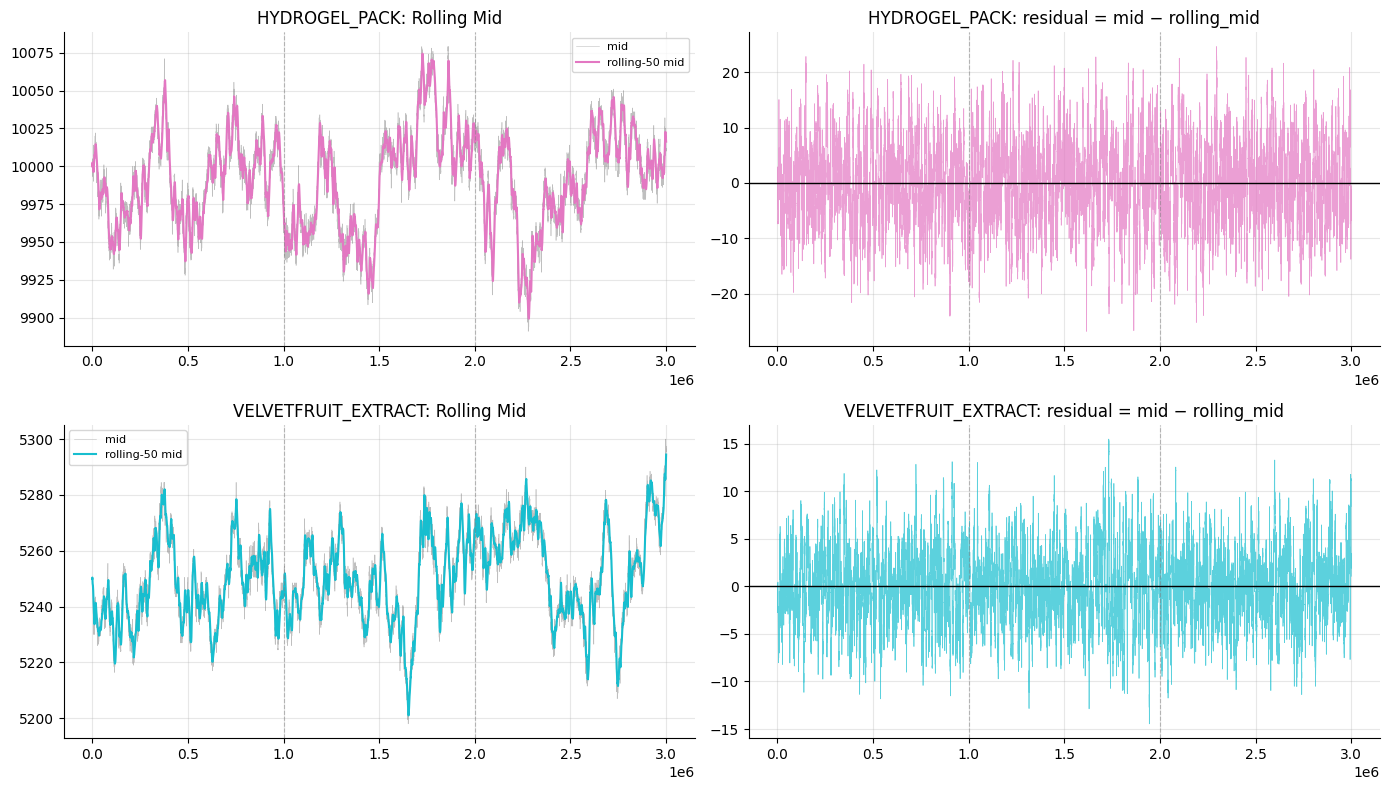

Product                        AC(1)       Interpretation
────────────────────────────────────────────────────────────
HYDROGEL_PACK                -0.0253          random walk
VELVETFRUIT_EXTRACT          -0.0578          random walk


In [50]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
ac_results = {}
for row, product in enumerate(DELTA1):
    p = prices_all[prices_all['product'] == product].copy().sort_values('time_index')
    p['rolling_mid'] = p['mid_price'].rolling(50, min_periods=1).mean()
    p['residual'] = p['mid_price'] - p['rolling_mid']

    ax = axes[row, 0]
    ax.plot(p['time_index'], p['mid_price'], color='gray', linewidth=0.4, alpha=0.5, label='mid')
    ax.plot(p['time_index'], p['rolling_mid'], color=PROD_COLORS[product], linewidth=1.5, label='rolling-50 mid')
    for bday in [1, 2]: ax.axvline(bday * 1_000_000, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.set_title(f'{product}: Rolling Mid'); ax.legend(fontsize=8)

    ax = axes[row, 1]
    ax.plot(p['time_index'], p['residual'], color=PROD_COLORS[product], linewidth=0.5, alpha=0.7)
    ax.axhline(0, color='black', linewidth=1)
    for bday in [1, 2]: ax.axvline(bday * 1_000_000, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.set_title(f'{product}: residual = mid − rolling_mid')

    ac = p['residual'].dropna().autocorr(lag=51)
    ac_results[product] = ac

plt.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/eda_fair_value.png', dpi=150, bbox_inches='tight')
plt.show()

lines = ['Residual Mean-Reversion Test (lag-1 autocorrelation of mid − rolling_mid)', '']
header = f"{'Product':<25} {'AC(1)':>10} {'Interpretation':>20}"
lines.extend([header, '─'*60])
print(header); print('─'*60)
for product, ac in ac_results.items():
    interp = 'mean-reverting' if ac < -0.1 else ('momentum' if ac > 0.1 else 'random walk')
    line = f"{product:<25} {ac:>10.4f} {interp:>20}"
    print(line); lines.append(line)
with open(f'{OUTPUT_DIR}/eda_autocorrelation.txt', 'w') as f:
    f.write('\n'.join(lines) + '\n')

---
# Section B — Voucher (Options) Analysis

The 10 `VEV_{K}` products are European call options on `VELVETFRUIT_EXTRACT` (VEE). All artifacts prefixed `eda_opt_*`.

**Conventions:**
- Risk-free rate `r = 0` (Prosperity doesn't define one).
- Time in years = TTE_days / 365.
- At the start of round 3 live trading: TTE = 5d = 5/365 yr.

## B.1 Chain Overview & Liquidity Screen

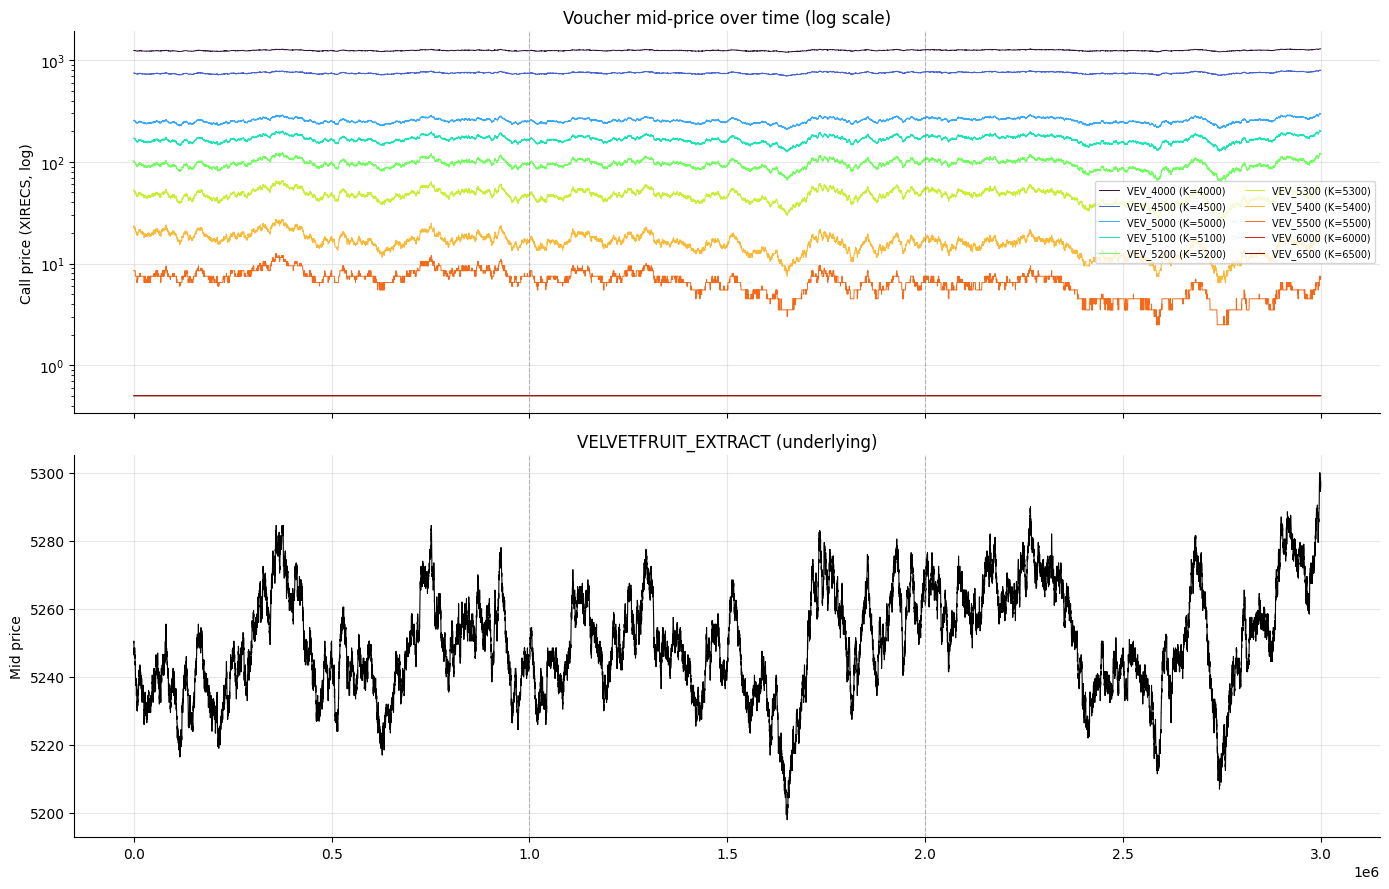

In [51]:
# Pivot wide: mid_price per product per timestamp
wide_mid = prices_all.pivot_table(index='time_index', columns='product', values='mid_price', aggfunc='last')
wide_mid = wide_mid.sort_index()

# Plot all voucher mid prices on shared axes (log scale helps given wide range)
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
cmap = plt.get_cmap('turbo')
for i, v in enumerate(VOUCHERS):
    if v in wide_mid.columns:
        axes[0].plot(wide_mid.index, wide_mid[v], label=f'{v} (K={VOUCHER_STRIKE[v]})',
                     linewidth=0.7, color=cmap(i / max(1, len(VOUCHERS)-1)))
axes[0].set_yscale('log')
axes[0].set_title('Voucher mid-price over time (log scale)')
axes[0].set_ylabel('Call price (XIRECS, log)')
axes[0].legend(fontsize=7, ncol=2)
for bday in [1, 2]: axes[0].axvline(bday * 1_000_000, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

# VEE underlying
if UNDERLYING in wide_mid.columns:
    axes[1].plot(wide_mid.index, wide_mid[UNDERLYING], color='black', linewidth=0.8)
    axes[1].set_title(f'{UNDERLYING} (underlying)'); axes[1].set_ylabel('Mid price')
for bday in [1, 2]: axes[1].axvline(bday * 1_000_000, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

plt.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/eda_opt_chain_overview.png', dpi=150, bbox_inches='tight')
plt.show()

In [52]:
wide_mid

product,HYDROGEL_PACK,VELVETFRUIT_EXTRACT,VEV_4000,VEV_4500,VEV_5000,VEV_5100,VEV_5200,VEV_5300,VEV_5400,VEV_5500,VEV_6000,VEV_6500
time_index,,,,,,,,,,,,
0,10000.0,5250.0,1250.0,750.0,257.0,171.5,101.5,53.0,23.0,8.5,0.5,0.5
100,10000.0,5250.5,1250.5,751.0,258.0,172.0,102.5,53.0,23.5,8.5,0.5,0.5
200,10003.0,5250.5,1250.5,750.0,257.0,172.0,102.5,53.0,23.5,8.5,0.5,0.5
300,10002.0,5250.5,1250.5,750.0,257.5,172.0,102.5,53.0,23.5,8.5,0.5,0.5
400,10003.0,5250.5,1250.5,750.0,257.0,172.0,102.5,53.0,23.5,8.5,0.5,0.5
...,...,...,...,...,...,...,...,...,...,...,...,...
2999500,10010.0,5295.5,1296.0,795.5,297.5,201.5,119.5,58.0,20.5,7.0,0.5,0.5
2999600,10012.0,5296.5,1297.0,796.5,297.5,202.5,120.0,59.0,20.5,7.5,0.5,0.5
2999700,10012.0,5297.5,1297.0,797.5,298.5,203.0,120.5,59.0,20.5,7.5,0.5,0.5


In [53]:
# Liquidity / activity table per voucher
lines = ['Voucher liquidity & activity screen (all 3 historical days)', '']
header = f"{'Voucher':<10} {'K':>6} {'#ticks':>8} {'#trades':>8} {'mean_mid':>10} {'std_mid':>9} {'min':>7} {'max':>7} {'pinned@0.5':>11}"
lines.extend([header, '─' * 95])
print(header); print('─' * 95)

for v in VOUCHERS:
    p = prices_all[prices_all['product'] == v]
    t = trades_all[trades_all['symbol'] == v]
    mid = p['mid_price']
    pinned = bool((mid == 0.5).mean() > 0.99)
    line = (f"{v:<10} {VOUCHER_STRIKE[v]:>6} {len(p):>8} {len(t):>8} "
            f"{mid.mean():>10.2f} {mid.std():>9.3f} {mid.min():>7.1f} {mid.max():>7.1f} "
            f"{'YES' if pinned else 'no':>11}")
    print(line); lines.append(line)

lines.append('')
lines.append('Pinned vouchers (mid ≡ 0.5) are effectively dead — skip them in the trader.')
with open(f'{OUTPUT_DIR}/eda_opt_liquidity.txt', 'w') as f:
    f.write('\n'.join(lines) + '\n')

Voucher         K   #ticks  #trades   mean_mid   std_mid     min     max  pinned@0.5
───────────────────────────────────────────────────────────────────────────────────────────────
VEV_4000     4000    30000      464    1250.11    15.647  1198.0  1300.0          no
VEV_4500     4500    30000        1     750.11    15.640   698.5   799.5          no
VEV_5000     5000    30000        1     255.02    14.376   206.5   300.5          no
VEV_5100     5100    30000        1     166.81    12.743   125.0   205.5          no
VEV_5200     5200    30000       18      95.55     9.664    64.0   122.5          no
VEV_5300     5300    30000      121      46.76     6.228    26.5    65.5          no
VEV_5400     5400    30000      225      15.95     3.429     6.5    27.0          no
VEV_5500     5500    30000      267       6.64     1.739     2.5    12.5          no
VEV_6000     6000    30000      284       0.50     0.000     0.5     0.5         YES
VEV_6500     6500    30000      284       0.50     0.0

## B.2 No-Arbitrage Sanity Checks

For European calls on the same underlying/expiry:
1. **Monotonicity in strike**: C(K) non-increasing.
2. **Convexity in strike**: C(K1) − 2 C(K2) + C(K3) ≥ 0.
3. **Intrinsic lower bound**: C ≥ max(S − K, 0) (r=0, no dividend).
4. **Upper bound**: C ≤ S.

In [54]:
# Build wide frame with VEE + all vouchers aligned per timestamp
cols_needed = [UNDERLYING] + VOUCHERS
wide = wide_mid[[c for c in cols_needed if c in wide_mid.columns]].dropna(how='any')
print(f'Aligned ticks (all products present): {len(wide):,}')

S = wide[UNDERLYING].values
C = {v: wide[v].values for v in VOUCHERS if v in wide.columns}

# Sort strikes for monotonicity / convexity tests
sorted_vouchers = sorted([v for v in VOUCHERS if v in wide.columns], key=lambda v: VOUCHER_STRIKE[v])

# 1. Monotonicity in strike
mono_viol = np.zeros(len(wide), dtype=int)
for i in range(len(sorted_vouchers) - 1):
    v1, v2 = sorted_vouchers[i], sorted_vouchers[i+1]
    mono_viol += (C[v1] < C[v2]).astype(int)
mono_viol_rate = (mono_viol > 0).mean()

# 2. Convexity in strike
conv_viol = np.zeros(len(wide), dtype=int)
for i in range(len(sorted_vouchers) - 2):
    v1, v2, v3 = sorted_vouchers[i], sorted_vouchers[i+1], sorted_vouchers[i+2]
    conv = C[v1] - 2 * C[v2] + C[v3]
    conv_viol += (conv < -1e-9).astype(int)
conv_viol_rate = (conv_viol > 0).mean()

# 3 & 4. Intrinsic bounds per voucher
intrinsic_viol = {}
upper_viol = {}
for v in sorted_vouchers:
    K = VOUCHER_STRIKE[v]
    intrinsic = np.maximum(S - K, 0.0)
    intrinsic_viol[v] = (C[v] < intrinsic - 1e-9).mean()
    upper_viol[v] = (C[v] > S + 1e-9).mean()

# Summary
lines = ['No-Arbitrage Violation Summary (fraction of aligned ticks)', '']
lines.append(f'Monotonicity C(K↑) non-increasing : violation rate = {mono_viol_rate:.4%}')
lines.append(f'Convexity C(K1)-2C(K2)+C(K3) ≥ 0   : violation rate = {conv_viol_rate:.4%}')
lines.append('')
lines.append(f"{'Voucher':<10} {'K':>6} {'C < max(S-K,0)':>18} {'C > S':>10}")
lines.append('─' * 55)
for v in sorted_vouchers:
    lines.append(f"{v:<10} {VOUCHER_STRIKE[v]:>6} {intrinsic_viol[v]:>17.4%} {upper_viol[v]:>9.4%}")
for L in lines: print(L)
with open(f'{OUTPUT_DIR}/eda_opt_arbitrage_stats.txt', 'w') as f:
    f.write('\n'.join(lines) + '\n')

Aligned ticks (all products present): 30,000
No-Arbitrage Violation Summary (fraction of aligned ticks)

Monotonicity C(K↑) non-increasing : violation rate = 0.0000%
Convexity C(K1)-2C(K2)+C(K3) ≥ 0   : violation rate = 0.0300%

Voucher         K     C < max(S-K,0)      C > S
───────────────────────────────────────────────────────
VEV_4000     4000           9.9533%   0.0000%
VEV_4500     4500          29.3733%   0.0000%
VEV_5000     5000           0.0100%   0.0000%
VEV_5100     5100           0.0000%   0.0000%
VEV_5200     5200           0.0000%   0.0000%
VEV_5300     5300           0.0000%   0.0000%
VEV_5400     5400           0.0000%   0.0000%
VEV_5500     5500           0.0000%   0.0000%
VEV_6000     6000           0.0000%   0.0000%
VEV_6500     6500           0.0000%   0.0000%


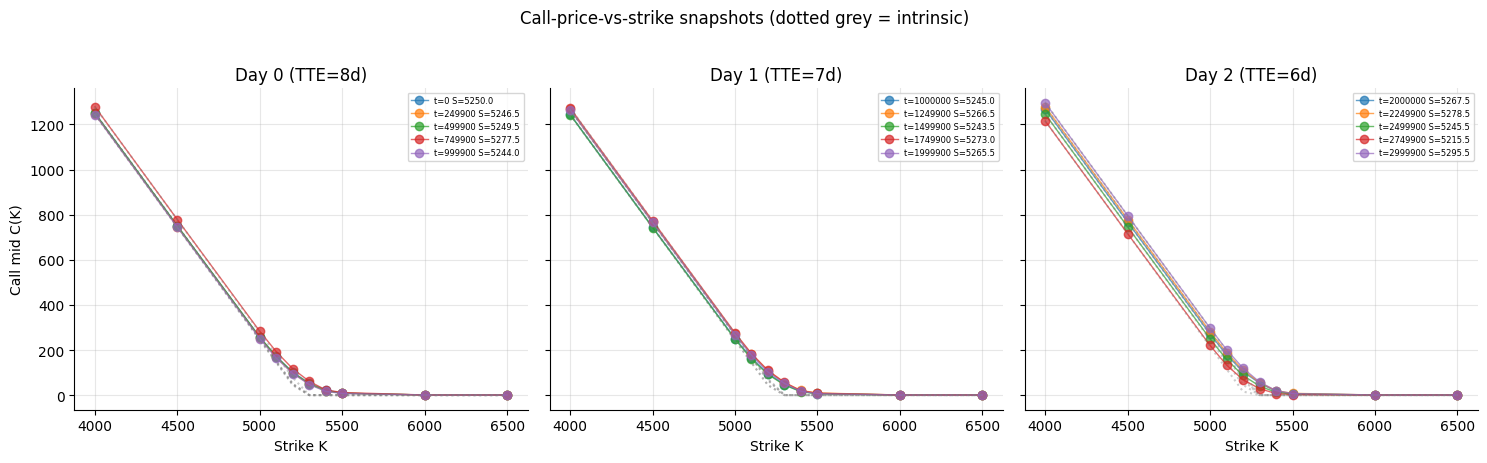

In [55]:
# Plot call price vs strike at a few representative snapshots per day
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, day in zip(axes, DAYS):
    day_mask = (wide.index >= day * 1_000_000) & (wide.index < (day + 1) * 1_000_000)
    sub = wide.loc[day_mask]
    if len(sub) == 0:
        continue
    # sample 5 timestamps
    idxs = np.linspace(0, len(sub) - 1, 5).astype(int)
    for ii, ridx in enumerate(idxs):
        S_t = sub.iloc[ridx][UNDERLYING]
        Ks = [VOUCHER_STRIKE[v] for v in sorted_vouchers]
        Cs = [sub.iloc[ridx][v] for v in sorted_vouchers]
        ax.plot(Ks, Cs, marker='o', linewidth=1.0, alpha=0.7, label=f't={sub.index[ridx]} S={S_t:.1f}')
        # intrinsic
        intr = [max(S_t - K, 0) for K in Ks]
        ax.plot(Ks, intr, linestyle=':', color='gray', alpha=0.4)
    ax.set_title(f'Day {day} (TTE={TTE_BY_DAY[day]}d)')
    ax.set_xlabel('Strike K'); ax.legend(fontsize=6)
axes[0].set_ylabel('Call mid C(K)')
fig.suptitle('Call-price-vs-strike snapshots (dotted grey = intrinsic)', y=1.02)
plt.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/eda_opt_arbitrage.png', dpi=150, bbox_inches='tight')
plt.show()

## B.3 Intrinsic vs Time Value

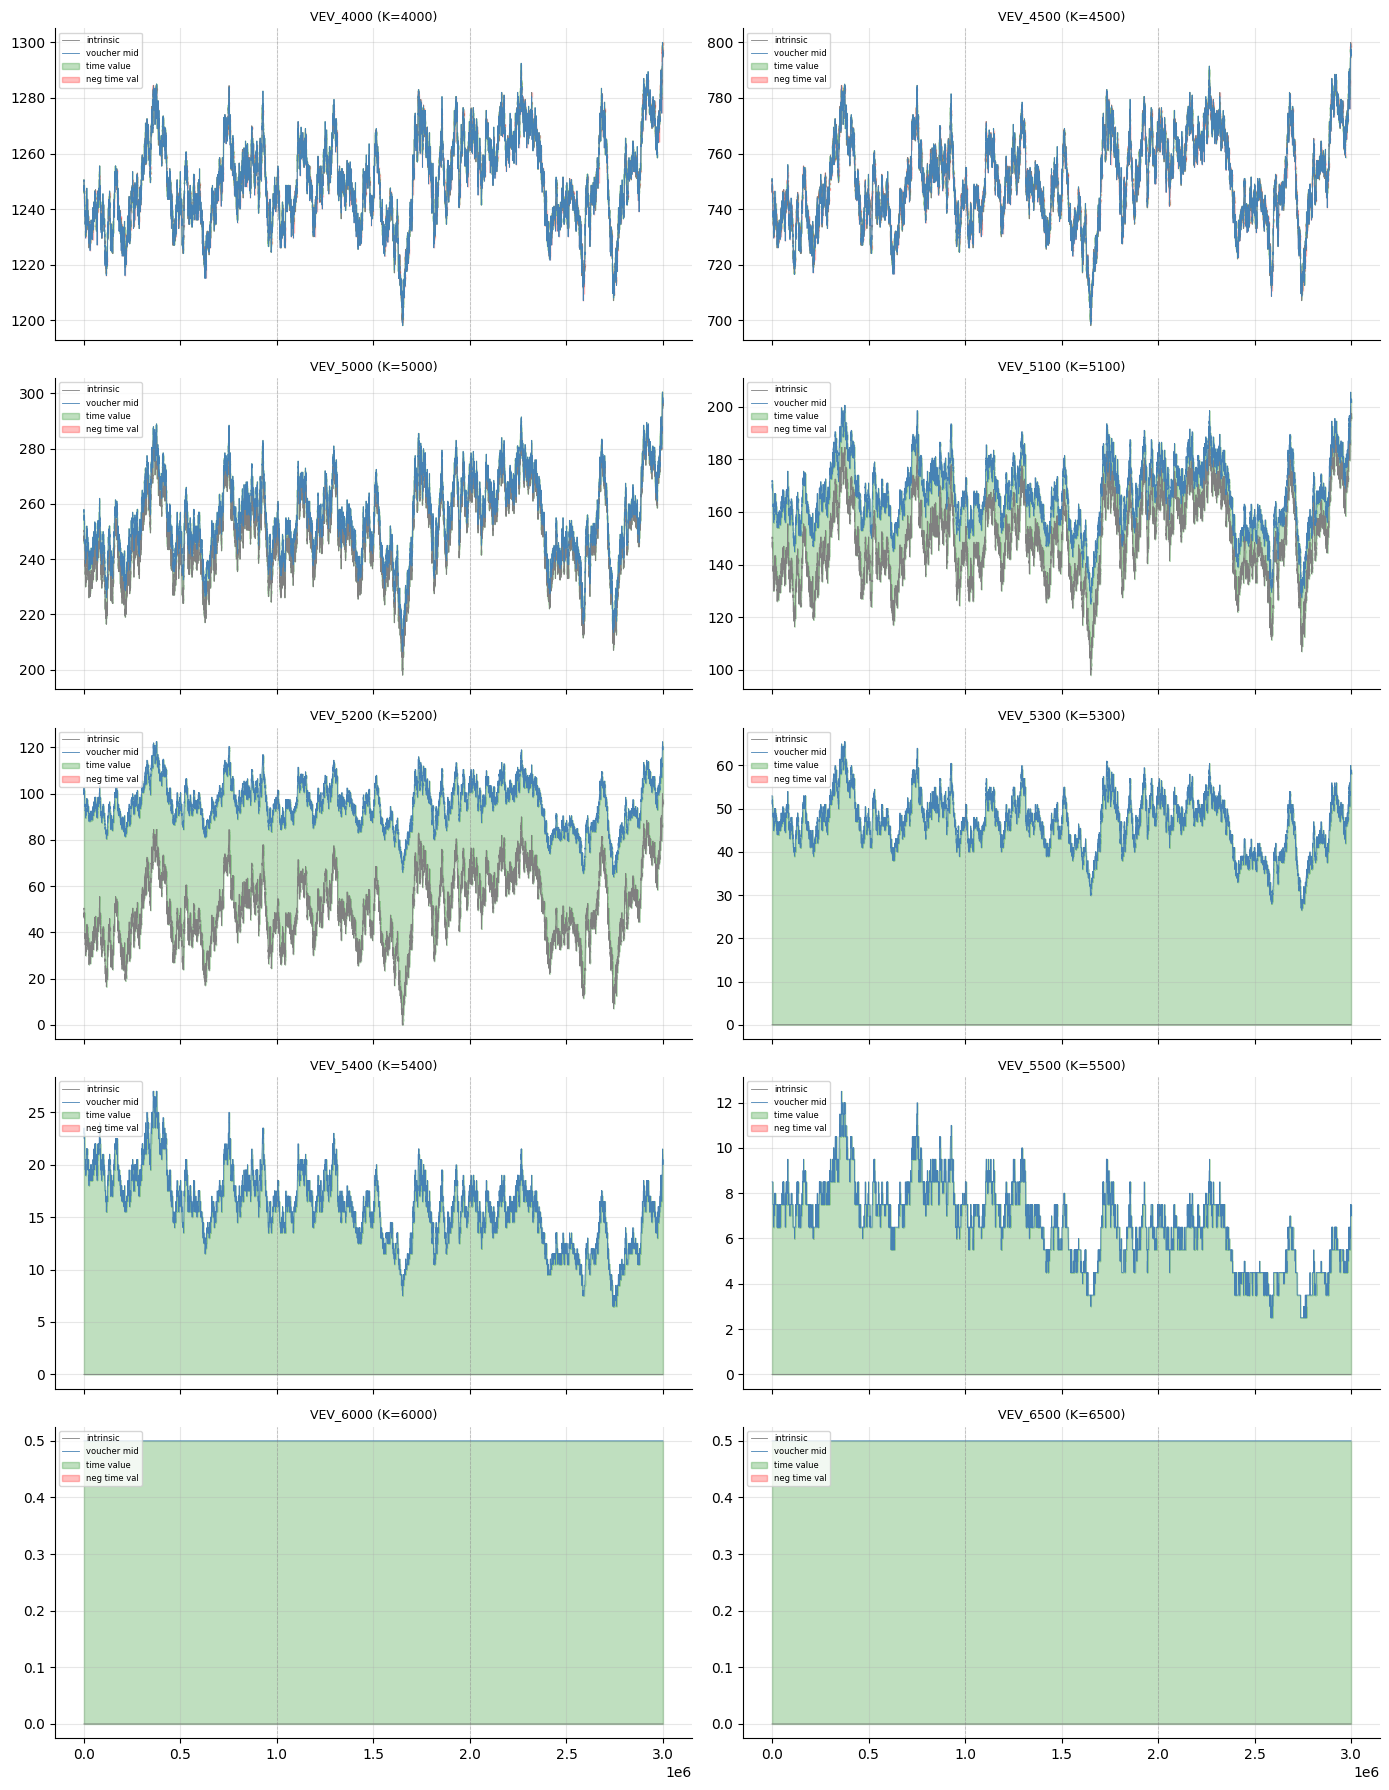

In [56]:
fig, axes = plt.subplots(5, 2, figsize=(14, 18), sharex=True)
for ax, v in zip(axes.flat, sorted_vouchers):
    K = VOUCHER_STRIKE[v]
    sub = wide[[UNDERLYING, v]].copy()
    sub['intrinsic'] = np.maximum(sub[UNDERLYING] - K, 0.0)
    sub['time_val'] = sub[v] - sub['intrinsic']
    ax.plot(sub.index, sub['intrinsic'], color='gray', linewidth=0.6, label='intrinsic')
    ax.plot(sub.index, sub[v], color='steelblue', linewidth=0.6, label='voucher mid')
    ax.fill_between(sub.index, sub['intrinsic'], sub[v], where=(sub[v] >= sub['intrinsic']),
                    color='green', alpha=0.25, label='time value')
    ax.fill_between(sub.index, sub[v], sub['intrinsic'], where=(sub[v] < sub['intrinsic']),
                    color='red', alpha=0.25, label='neg time val')
    for bday in [1, 2]: ax.axvline(bday * 1_000_000, color='gray', linestyle='--', linewidth=0.6, alpha=0.4)
    ax.set_title(f'{v} (K={K})', fontsize=9); ax.legend(fontsize=6, loc='upper left')

plt.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/eda_opt_time_value.png', dpi=150, bbox_inches='tight')
plt.show()

In [57]:
# Time-value stats by day
lines = ['Intrinsic vs Time-Value Summary (per day)', '']
header = f"{'Day':>4} {'TTE':>4} {'Voucher':<10} {'K':>6} {'mean_C':>9} {'mean_intr':>10} {'mean_TV':>9} {'%TV>0':>7}"
lines.extend([header, '─' * 75])
print(header); print('─' * 75)
for day in DAYS:
    day_mask = (wide.index >= day * 1_000_000) & (wide.index < (day + 1) * 1_000_000)
    sub = wide.loc[day_mask]
    for v in sorted_vouchers:
        K = VOUCHER_STRIKE[v]
        C_ = sub[v].values
        intr = np.maximum(sub[UNDERLYING].values - K, 0.0)
        tv = C_ - intr
        line = (f"{day:>4} {TTE_BY_DAY[day]:>4} {v:<10} {K:>6} {np.mean(C_):>9.2f} "
                f"{np.mean(intr):>10.2f} {np.mean(tv):>9.2f} {(tv > 0).mean()*100:>6.1f}%")
        print(line); lines.append(line)
    lines.append(''); print('')
with open(f'{OUTPUT_DIR}/eda_opt_time_value_stats.txt', 'w') as f:
    f.write('\n'.join(lines) + '\n')

 Day  TTE Voucher         K    mean_C  mean_intr   mean_TV   %TV>0
───────────────────────────────────────────────────────────────────────────
   0    8 VEV_4000     4000   1246.52    1246.51      0.01    9.8%
   0    8 VEV_4500     4500    746.52     746.51      0.01   30.1%
   0    8 VEV_5000     5000    253.26     246.51      6.75  100.0%
   0    8 VEV_5100     5100    168.11     146.51     21.60  100.0%
   0    8 VEV_5200     5200     97.47      46.51     50.96  100.0%
   0    8 VEV_5300     5300     48.89       0.00     48.89  100.0%
   0    8 VEV_5400     5400     18.47       0.00     18.47  100.0%
   0    8 VEV_5500     5500      8.06       0.00      8.06  100.0%
   0    8 VEV_6000     6000      0.50       0.00      0.50  100.0%
   0    8 VEV_6500     6500      0.50       0.00      0.50  100.0%

   1    7 VEV_4000     4000   1248.41    1248.39      0.02   10.0%
   1    7 VEV_4500     4500    748.41     748.39      0.01   30.4%
   1    7 VEV_5000     5000    253.26     248.39    

## B.4 Moneyness & Empirical Delta

Empirical delta = OLS slope of tick-level ΔC on ΔS, per strike per day.

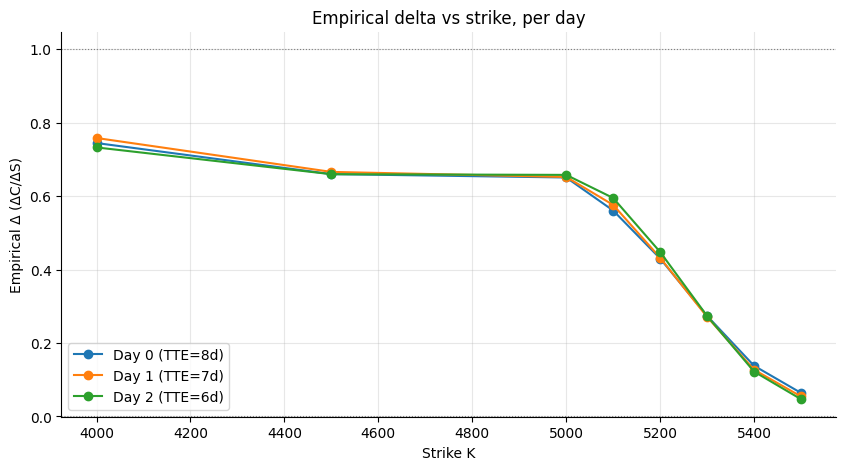

 day  tte  voucher    K  delta_emp    n
   0    8 VEV_4000 4000   0.744474 9999
   0    8 VEV_4500 4500   0.659843 9999
   0    8 VEV_5000 5000   0.650663 9999
   0    8 VEV_5100 5100   0.560695 9999
   0    8 VEV_5200 5200   0.429985 9999
   0    8 VEV_5300 5300   0.273647 9999
   0    8 VEV_5400 5400   0.137859 9999
   0    8 VEV_5500 5500   0.063822 9999
   0    8 VEV_6000 6000        NaN 9999
   0    8 VEV_6500 6500        NaN 9999
   1    7 VEV_4000 4000   0.758207 9999
   1    7 VEV_4500 4500   0.665889 9999
   1    7 VEV_5000 5000   0.652066 9999
   1    7 VEV_5100 5100   0.575960 9999
   1    7 VEV_5200 5200   0.432058 9999
   1    7 VEV_5300 5300   0.271031 9999
   1    7 VEV_5400 5400   0.127012 9999
   1    7 VEV_5500 5500   0.054265 9999
   1    7 VEV_6000 6000        NaN 9999
   1    7 VEV_6500 6500        NaN 9999
   2    6 VEV_4000 4000   0.732538 9999
   2    6 VEV_4500 4500   0.659606 9999
   2    6 VEV_5000 5000   0.657733 9999
   2    6 VEV_5100 5100   0.594821 9999


In [58]:
# First differences per day (avoid mixing across day boundaries)
delta_rows = []
for day in DAYS:
    day_mask = (wide.index >= day * 1_000_000) & (wide.index < (day + 1) * 1_000_000)
    sub = wide.loc[day_mask]
    dS = sub[UNDERLYING].diff().dropna()
    for v in sorted_vouchers:
        dC = sub[v].diff().dropna()
        common = dS.index.intersection(dC.index)
        x = dS.loc[common].values
        y = dC.loc[common].values
        # skip if voucher is pinned
        if np.std(y) < 1e-9:
            delta_rows.append({'day': day, 'tte': TTE_BY_DAY[day], 'voucher': v, 'K': VOUCHER_STRIKE[v],
                               'delta_emp': np.nan, 'n': len(x)})
            continue
        # OLS slope
        denom = np.var(x)
        slope = np.cov(x, y, ddof=0)[0, 1] / denom if denom > 0 else np.nan
        delta_rows.append({'day': day, 'tte': TTE_BY_DAY[day], 'voucher': v, 'K': VOUCHER_STRIKE[v],
                           'delta_emp': slope, 'n': len(x)})

delta_df = pd.DataFrame(delta_rows)
# plot
fig, ax = plt.subplots(figsize=(10, 5))
for day in DAYS:
    sub = delta_df[delta_df['day'] == day].sort_values('K')
    ax.plot(sub['K'], sub['delta_emp'], marker='o',
            color=DAY_COLORS[day], label=f'Day {day} (TTE={TTE_BY_DAY[day]}d)')
ax.axhline(1.0, color='gray', linestyle=':', linewidth=0.8)
ax.axhline(0.0, color='gray', linestyle=':', linewidth=0.8)
ax.set_xlabel('Strike K'); ax.set_ylabel('Empirical Δ (ΔC/ΔS)')
ax.set_title('Empirical delta vs strike, per day')
ax.legend()
fig.savefig(f'{OUTPUT_DIR}/eda_opt_delta_empirical.png', dpi=150, bbox_inches='tight')
plt.show()

with open(f'{OUTPUT_DIR}/eda_opt_delta_stats.txt', 'w') as f:
    f.write('Empirical delta per voucher per day\n\n')
    f.write(delta_df.to_string(index=False))
    f.write('\n')
print(delta_df.to_string(index=False))

## B.5 Implied-Volatility Surface

Black-Scholes European call (r=0, q=0):
$$C = S\,N(d_1) - K\,N(d_2),\quad d_1 = \frac{\ln(S/K) + 0.5\sigma^2 T}{\sigma\sqrt{T}},\ d_2 = d_1 - \sigma\sqrt{T}.$$

IV is solved with Brent on the call-price function. Strikes pinned at 0.5 are skipped (uninformative).

In [59]:
TRADING_DAYS_PER_YEAR = 365.0

def bs_call(S, K, T, sigma):
    if T <= 0 or sigma <= 0:
        return max(S - K, 0.0)
    d1 = (math.log(S / K) + 0.5 * sigma * sigma * T) / (sigma * math.sqrt(T))
    d2 = d1 - sigma * math.sqrt(T)
    return S * norm.cdf(d1) - K * norm.cdf(d2)

def bs_delta(S, K, T, sigma):
    if T <= 0 or sigma <= 0:
        return 1.0 if S > K else (0.5 if S == K else 0.0)
    d1 = (math.log(S / K) + 0.5 * sigma * sigma * T) / (sigma * math.sqrt(T))
    return norm.cdf(d1)

def implied_vol(C_obs, S, K, T, lo=1e-4, hi=5.0):
    # Guard: need intrinsic ≤ C_obs ≤ S
    intrinsic = max(S - K, 0.0)
    if C_obs < intrinsic - 1e-6 or C_obs > S + 1e-6:
        return np.nan
    if C_obs <= intrinsic + 1e-6:
        return np.nan  # at or below intrinsic, IV→0 and uninformative
    try:
        return brentq(lambda s: bs_call(S, K, T, s) - C_obs, lo, hi, maxiter=100, xtol=1e-6)
    except Exception:
        return np.nan

# Sample every 500 ticks for speed
SAMPLE_STEP = 500

iv_rows = []
for day in DAYS:
    day_mask = (wide.index >= day * 1_000_000) & (wide.index < (day + 1) * 1_000_000)
    sub = wide.loc[day_mask].iloc[::SAMPLE_STEP]
    T = TTE_BY_DAY[day] / TRADING_DAYS_PER_YEAR
    for ts, row in sub.iterrows():
        S_t = row[UNDERLYING]
        for v in sorted_vouchers:
            K = VOUCHER_STRIKE[v]
            C_obs = row[v]
            if C_obs <= 0.5001:  # pinned/dead
                continue
            iv = implied_vol(C_obs, S_t, K, T)
            iv_rows.append({'day': day, 'tte': TTE_BY_DAY[day], 'ts': ts,
                            'voucher': v, 'K': K, 'S': S_t, 'C': C_obs, 'iv': iv,
                            'logm': math.log(S_t / K)})

iv_df = pd.DataFrame(iv_rows)
print(f'Computed IVs for {len(iv_df)} (day, ts, strike) points')
iv_summary = iv_df.dropna(subset=['iv']).groupby(['day', 'tte', 'voucher', 'K']).agg(
    mean_iv=('iv', 'mean'), std_iv=('iv', 'std'), n=('iv', 'size')
).reset_index()
print(iv_summary)

Computed IVs for 480 (day, ts, strike) points
    day  tte   voucher     K   mean_iv    std_iv   n
0     0    8  VEV_4000  4000  0.800574  0.151495   2
1     0    8  VEV_4500  4500  0.434455  0.057866   5
2     0    8  VEV_5000  5000  0.232873  0.006956  20
3     0    8  VEV_5100  5100  0.236524  0.003720  20
4     0    8  VEV_5200  5200  0.232002  0.003816  20
5     0    8  VEV_5300  5300  0.232297  0.004144  20
6     0    8  VEV_5400  5400  0.222510  0.009580  20
7     0    8  VEV_5500  5500  0.238246  0.002572  20
8     1    7  VEV_4000  4000  0.809017  0.138274   3
9     1    7  VEV_4500  4500  0.459012  0.049758   6
10    1    7  VEV_5000  5000  0.233229  0.007712  20
11    1    7  VEV_5100  5100  0.229568  0.007890  20
12    1    7  VEV_5200  5200  0.235799  0.006062  20
13    1    7  VEV_5300  5300  0.238869  0.003359  20
14    1    7  VEV_5400  5400  0.221342  0.006644  20
15    1    7  VEV_5500  5500  0.241575  0.007169  20
16    2    6  VEV_4000  4000  0.785754  0.011506   4


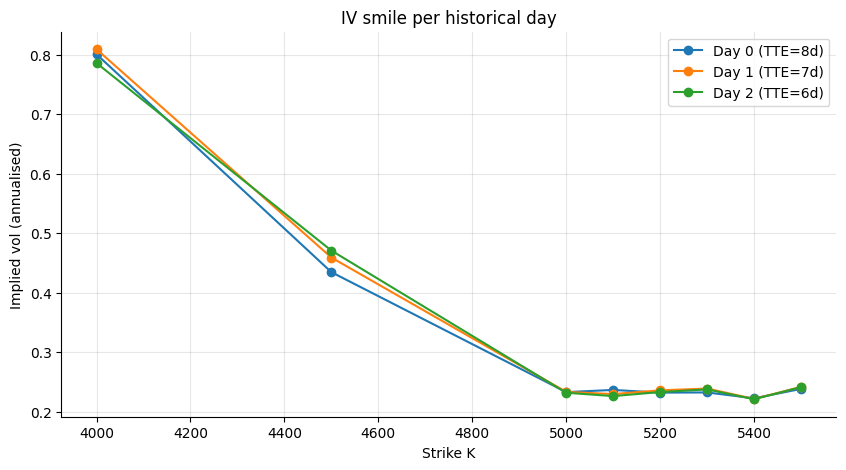

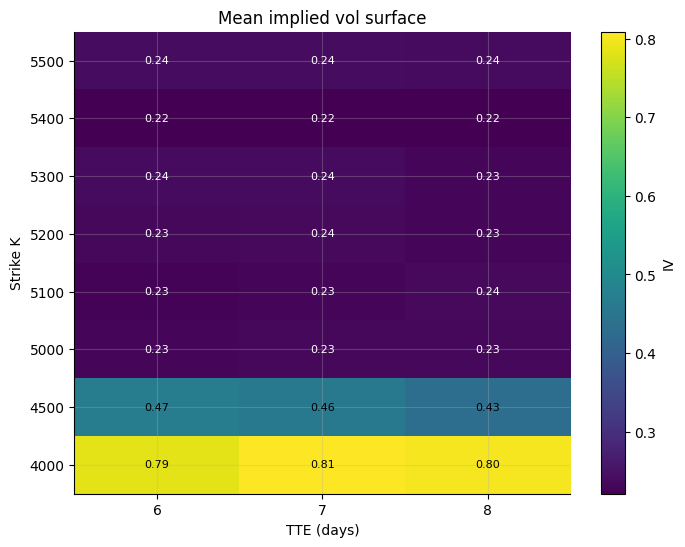

In [60]:
# IV smile per day
fig, ax = plt.subplots(figsize=(10, 5))
for day in DAYS:
    sub = iv_df[iv_df['day'] == day].dropna(subset=['iv'])
    by_K = sub.groupby('K')['iv'].mean().reset_index().sort_values('K')
    ax.plot(by_K['K'], by_K['iv'], marker='o',
            color=DAY_COLORS[day], label=f'Day {day} (TTE={TTE_BY_DAY[day]}d)')
ax.set_xlabel('Strike K'); ax.set_ylabel('Implied vol (annualised)')
ax.set_title('IV smile per historical day')
ax.legend()
fig.savefig(f'{OUTPUT_DIR}/eda_opt_iv_smile.png', dpi=150, bbox_inches='tight')
plt.show()

# IV surface heatmap (mean IV over strike × TTE)
pivot = iv_summary.pivot_table(index='K', columns='tte', values='mean_iv')
pivot = pivot.sort_index().sort_index(axis=1)
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(pivot.values, aspect='auto', origin='lower', cmap='viridis')
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index)
ax.set_xlabel('TTE (days)'); ax.set_ylabel('Strike K')
ax.set_title('Mean implied vol surface')
plt.colorbar(im, ax=ax, label='IV')
# annotate
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.values[i, j]
        if pd.notna(val):
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    color='white' if val < 0.5 * np.nanmax(pivot.values) else 'black', fontsize=8)
fig.savefig(f'{OUTPUT_DIR}/eda_opt_iv_surface.png', dpi=150, bbox_inches='tight')
plt.show()

# Save text summary
with open(f'{OUTPUT_DIR}/eda_opt_iv_stats.txt', 'w') as f:
    f.write('Implied vol summary (mean ± std per voucher per day)\n\n')
    f.write(iv_summary.to_string(index=False))
    f.write('\n')

## B.6 Realized vs Implied Volatility

Realized vol of VEE log returns, annualised assuming 10 000 ticks/day × 365 days = 3 650 000 ticks/year.

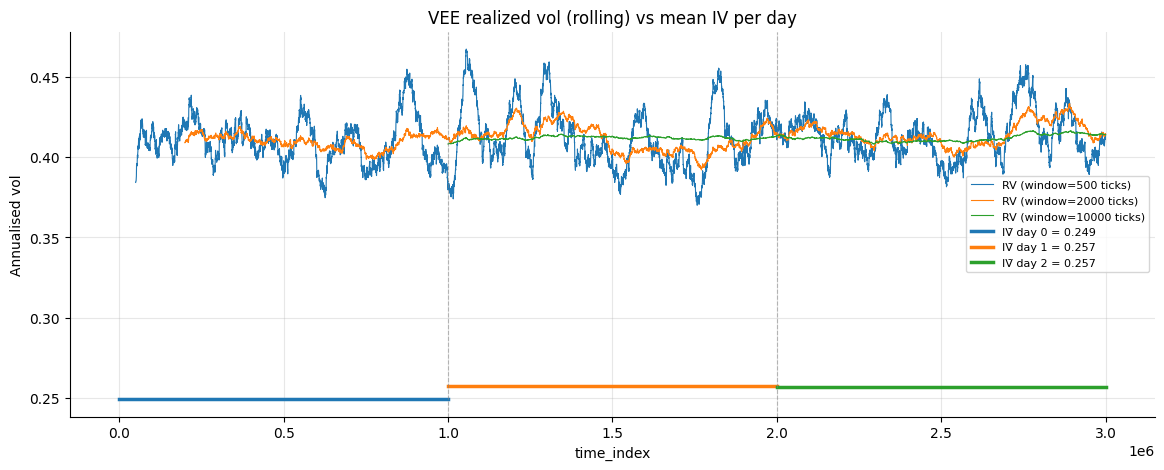

 Day  TTE   RV_500  RV_2000   RV_10k   mean_IV
───────────────────────────────────────────────────────
   0    8    0.408    0.408    0.408     0.249
   1    7    0.413    0.413    0.413     0.257
   2    6    0.414    0.414    0.414     0.257


In [61]:
TICKS_PER_YEAR = 10_000 * TRADING_DAYS_PER_YEAR  # = 3.65e6

# log returns of VEE
vee = wide[UNDERLYING].dropna()
log_ret = np.log(vee).diff().dropna()

# rolling realized vol (per-tick std × sqrt(ticks per year))
rv = {}
for win in [500, 2000, 10000]:
    rv[win] = log_ret.rolling(win).std() * math.sqrt(TICKS_PER_YEAR)

fig, ax = plt.subplots(figsize=(14, 5))
for win, s in rv.items():
    ax.plot(s.index, s.values, linewidth=0.8, label=f'RV (window={win} ticks)')

# Overlay mean IV per day as horizontal segments
for day in DAYS:
    mean_iv_day = iv_df[iv_df['day'] == day]['iv'].mean()
    if pd.notna(mean_iv_day):
        xs = [day * 1_000_000, (day + 1) * 1_000_000]
        ax.plot(xs, [mean_iv_day, mean_iv_day], color=DAY_COLORS[day], linewidth=2.5,
                label=f'IV̄ day {day} = {mean_iv_day:.3f}')

for bday in [1, 2]: ax.axvline(bday * 1_000_000, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_title('VEE realized vol (rolling) vs mean IV per day')
ax.set_ylabel('Annualised vol'); ax.set_xlabel('time_index'); ax.legend(fontsize=8)
fig.savefig(f'{OUTPUT_DIR}/eda_opt_rv_vs_iv.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary
lines = ['Realized vs Implied Vol (annualised, TICKS_PER_YEAR=10000*365)', '']
header = f"{'Day':>4} {'TTE':>4} {'RV_500':>8} {'RV_2000':>8} {'RV_10k':>8} {'mean_IV':>9}"
lines.extend([header, '─' * 55])
print(header); print('─' * 55)
for day in DAYS:
    mask = (log_ret.index >= day * 1_000_000) & (log_ret.index < (day + 1) * 1_000_000)
    sub_ret = log_ret.loc[mask]
    rv_day = {w: sub_ret.std() * math.sqrt(TICKS_PER_YEAR) for w in [500, 2000, 10000]}  # ex-post day RV
    mean_iv_day = iv_df[iv_df['day'] == day]['iv'].mean()
    line = f"{day:>4} {TTE_BY_DAY[day]:>4} {rv_day[500]:>8.3f} {rv_day[2000]:>8.3f} {rv_day[10000]:>8.3f} {mean_iv_day:>9.3f}"
    print(line); lines.append(line)

lines.append('')
lines.append('Interpretation: if IV >> RV → vouchers overpriced → prefer selling vol.')
lines.append('                if IV << RV → vouchers underpriced → prefer buying vol.')
with open(f'{OUTPUT_DIR}/eda_opt_rv_vs_iv_stats.txt', 'w') as f:
    f.write('\n'.join(lines) + '\n')

## B.7 Correlation Matrix

Tick-level first-difference correlations. Confirms that HYDROGEL_PACK is independent of the VEE/voucher complex (or not), and which vouchers track VEE most tightly.

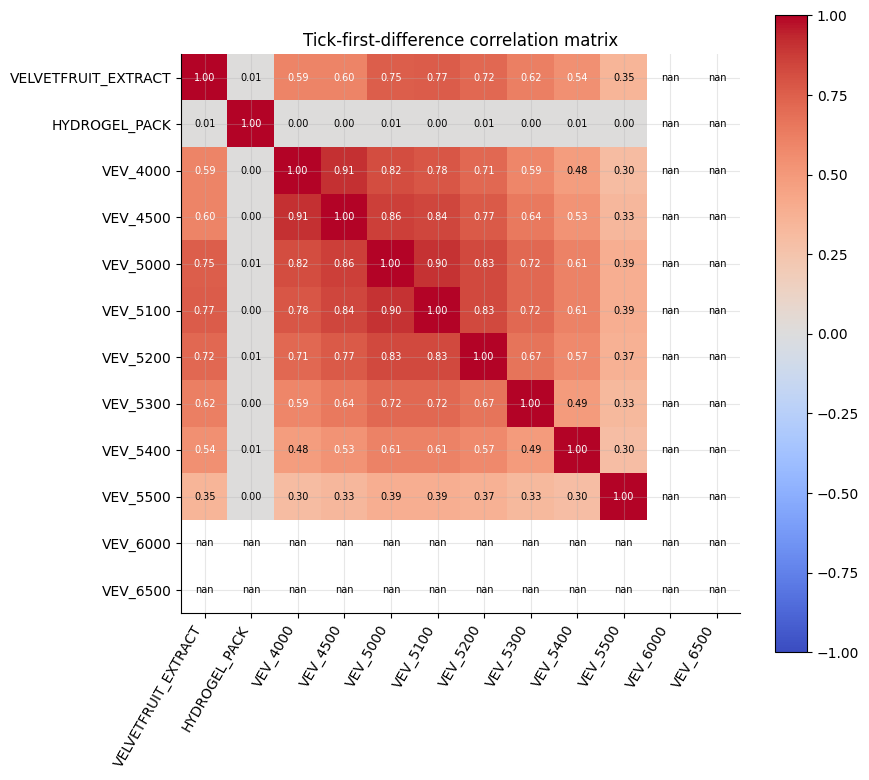

In [62]:
cols = [UNDERLYING, 'HYDROGEL_PACK'] + sorted_vouchers
cols = [c for c in cols if c in wide_mid.columns]
diffs = wide_mid[cols].diff().dropna(how='any')
# restrict to an aligned sub-frame
corr = diffs.corr()

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=60, ha='right')
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        v = corr.values[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                color='white' if abs(v) > 0.5 else 'black', fontsize=7)
ax.set_title('Tick-first-difference correlation matrix')
plt.colorbar(im, ax=ax)
plt.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/eda_opt_corr_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## B.8 Delta-Hedge Simulation (toy)

Hold +1 `VEV_5300` and short `Δ·VEE` using the prior tick's empirical delta; compare P&L variance to a naked long.

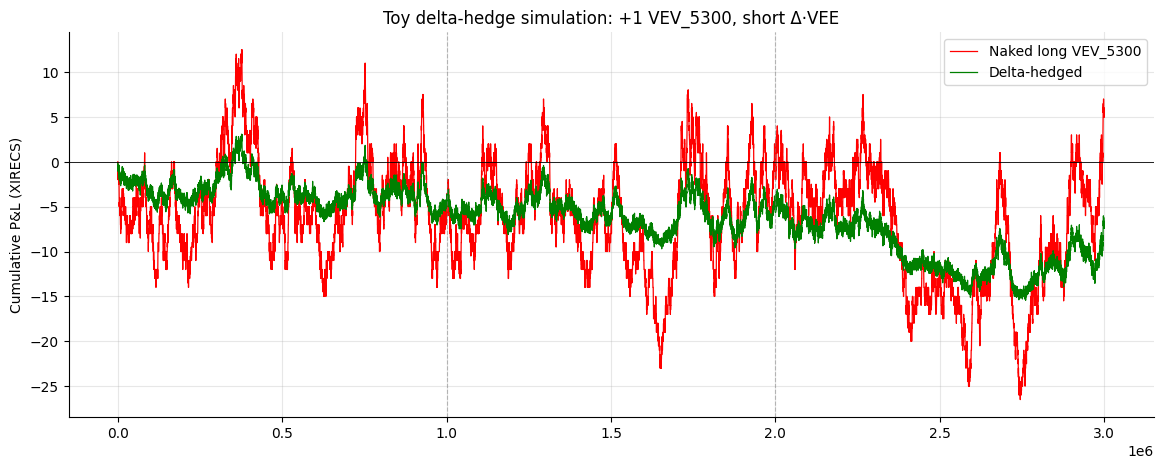

Delta-hedge simulation (VEV_5300, short Δ·VEE, no costs)

Ticks simulated : 29,999
Final P&L naked :      +5.00
Final P&L hedged:      -7.39
Std naked       :    +0.4962
Std hedged      :    +0.3887
Var reduction   :     +38.65%


In [63]:
HEDGE_V = 'VEV_5300'  # near-ATM-ish in this regime

# Use per-tick first-differences, and the empirical delta from B4 (day-level) as a constant
diff_full = wide_mid[[UNDERLYING, HEDGE_V]].diff().dropna()
delta_by_day = delta_df.set_index(['day', 'voucher'])['delta_emp'].to_dict()

pnls_naked = []
pnls_hedged = []
ts_list = []
for ts, row in diff_full.iterrows():
    day = int(ts // 1_000_000)
    dS = row[UNDERLYING]
    dC = row[HEDGE_V]
    delta = delta_by_day.get((day, HEDGE_V), np.nan)
    if pd.isna(delta):
        continue
    pnls_naked.append(dC)
    pnls_hedged.append(dC - delta * dS)
    ts_list.append(ts)

naked = np.array(pnls_naked); hedged = np.array(pnls_hedged)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ts_list, np.cumsum(naked), label=f'Naked long {HEDGE_V}', color='red', linewidth=0.9)
ax.plot(ts_list, np.cumsum(hedged), label='Delta-hedged', color='green', linewidth=0.9)
for bday in [1, 2]: ax.axvline(bday * 1_000_000, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axhline(0, color='black', linewidth=0.6)
ax.set_title(f'Toy delta-hedge simulation: +1 {HEDGE_V}, short Δ·VEE')
ax.set_ylabel('Cumulative P&L (XIRECS)')
ax.legend()
fig.savefig(f'{OUTPUT_DIR}/eda_opt_hedge_sim.png', dpi=150, bbox_inches='tight')
plt.show()

lines = [f'Delta-hedge simulation ({HEDGE_V}, short Δ·VEE, no costs)', '']
lines.append(f"Ticks simulated : {len(naked):,}")
lines.append(f"Final P&L naked : {naked.sum():>+10.2f}")
lines.append(f"Final P&L hedged: {hedged.sum():>+10.2f}")
lines.append(f"Std naked       : {naked.std():>+10.4f}")
lines.append(f"Std hedged      : {hedged.std():>+10.4f}")
lines.append(f"Var reduction   : {(1 - hedged.var()/naked.var())*100:>+10.2f}%")
for L in lines: print(L)
with open(f'{OUTPUT_DIR}/eda_opt_hedge_sim_stats.txt', 'w') as f:
    f.write('\n'.join(lines) + '\n')

---
# Section C — Summary Report

In [64]:
summary_lines = []
summary_lines.append('=' * 78)
summary_lines.append('  ROUND 3 EDA — KEY STATISTICS SUMMARY')
summary_lines.append('=' * 78)
print(summary_lines[-3]); print(summary_lines[-2]); print(summary_lines[-1])

# A. Delta-1 product summary blocks (round-2 template)
for product in DELTA1:
    p = prices_all[prices_all['product'] == product].copy()
    t = trades_all[trades_all['symbol'] == product].copy()
    p['spread'] = p['ask_price_1'] - p['bid_price_1']
    p['bid_depth'] = p[['bid_volume_1','bid_volume_2','bid_volume_3']].sum(axis=1)
    p['ask_depth'] = p[['ask_volume_1','ask_volume_2','ask_volume_3']].sum(axis=1)
    tot = p['bid_depth'] + p['ask_depth']
    p['imbalance'] = np.where(tot > 0, (p['bid_depth'] - p['ask_depth']) / tot, np.nan)

    p_sorted = p.sort_values('time_index').copy()
    p_sorted['rolling_mid'] = p_sorted['mid_price'].rolling(50, min_periods=1).mean()
    resid = (p_sorted['mid_price'] - p_sorted['rolling_mid']).dropna()
    ac = resid.autocorr(lag=1)
    interp = 'mean-reverting' if ac < -0.1 else ('momentum' if ac > 0.1 else 'random walk')
    s = p['spread'].dropna()
    vwap_all = (t['price'] * t['quantity']).sum() / t['quantity'].sum() if len(t) else float('nan')

    lines = [
        '',
        '─' * 78,
        f'  PRODUCT : {product}',
        '─' * 78,
        f'  Price range     : {p["mid_price"].min():.1f} – {p["mid_price"].max():.1f}',
        f'  Mean ± Std      : {p["mid_price"].mean():.2f} ± {p["mid_price"].std():.2f}',
        f'  CV (std/mean)   : {p["mid_price"].std() / p["mid_price"].mean():.5f}',
        f'  Residual AC-1   : {ac:.4f}  → {interp}',
        f'  Mean spread     : {s.mean():.3f} ticks (mode={s.mode().iloc[0]:.0f})',
        f'  % spread == 1   : {(s == 1).mean()*100:.1f}%',
        f'  Max spread      : {s.max():.0f} ticks',
        f'  Avg bid depth   : {p["bid_depth"].mean():.1f}',
        f'  Avg ask depth   : {p["ask_depth"].mean():.1f}',
        f'  Mean OB imbal.  : {p["imbalance"].mean():.4f}',
        f'  Total trades    : {len(t):,}',
        f'  Avg trade size  : {t["quantity"].mean():.1f}' if len(t) else '  Avg trade size  : N/A',
        f'  Overall VWAP    : {vwap_all:.2f}',
    ]
    for L in lines: print(L)
    summary_lines.extend(lines)

# B. Options summary
summary_lines.append('')
summary_lines.append('─' * 78)
summary_lines.append('  OPTIONS CHAIN SUMMARY')
summary_lines.append('─' * 78)
for L in summary_lines[-4:]: print(L)

header = f"  {'Voucher':<10} {'K':>6} {'pinned':>7} {'#trades':>8} {'emp_Δ_d2':>10} {'IV_d2':>8} {'TV_d2':>9}"
summary_lines.append(header); print(header)
summary_lines.append('  ' + '─' * 65); print(summary_lines[-1])
for v in sorted_vouchers:
    K = VOUCHER_STRIKE[v]
    mid = prices_all[prices_all['product'] == v]['mid_price']
    pinned = 'YES' if (mid == 0.5).mean() > 0.99 else 'no'
    n_tr = len(trades_all[trades_all['symbol'] == v])
    emp_d2 = delta_df[(delta_df['day'] == 2) & (delta_df['voucher'] == v)]['delta_emp'].iloc[0] if not delta_df[(delta_df['day'] == 2) & (delta_df['voucher'] == v)].empty else float('nan')
    iv_d2 = iv_df[(iv_df['day'] == 2) & (iv_df['voucher'] == v)]['iv'].mean()
    day_mask2 = (wide.index >= 2 * 1_000_000) & (wide.index < 3 * 1_000_000)
    sub = wide.loc[day_mask2]
    tv_d2 = (sub[v] - np.maximum(sub[UNDERLYING] - K, 0.0)).mean() if len(sub) else float('nan')
    line = f"  {v:<10} {K:>6} {pinned:>7} {n_tr:>8} {emp_d2:>10.3f} {iv_d2:>8.3f} {tv_d2:>9.2f}"
    print(line); summary_lines.append(line)

summary_lines.append('')
summary_lines.append('=' * 78)
with open(f'{OUTPUT_DIR}/eda_summary_report.txt', 'w') as f:
    f.write('\n'.join(summary_lines) + '\n')

  ROUND 3 EDA — KEY STATISTICS SUMMARY

──────────────────────────────────────────────────────────────────────────────
  PRODUCT : HYDROGEL_PACK
──────────────────────────────────────────────────────────────────────────────
  Price range     : 9891.0 – 10079.0
  Mean ± Std      : 9990.81 ± 31.94
  CV (std/mean)   : 0.00320
  Residual AC-1   : 0.9579  → momentum
  Mean spread     : 15.721 ticks (mode=16)
  % spread == 1   : 0.0%
  Max spread      : 17 ticks
  Avg bid depth   : 37.6
  Avg ask depth   : 37.6
  Mean OB imbal.  : -0.0001
  Total trades    : 1,010
  Avg trade size  : 4.0
  Overall VWAP    : 9990.75

──────────────────────────────────────────────────────────────────────────────
  PRODUCT : VELVETFRUIT_EXTRACT
──────────────────────────────────────────────────────────────────────────────
  Price range     : 5198.0 – 5300.0
  Mean ± Std      : 5250.10 ± 15.63
  CV (std/mean)   : 0.00298
  Residual AC-1   : 0.9571  → momentum
  Mean spread     : 4.988 ticks (mode=5)
  % spread =

---
## Strategic Recommendations

### Delta-1 products

- **`VELVETFRUIT_EXTRACT` (VEE)**: narrow range, moderate std (~14–17 per day). Good market-making candidate; also the hedge instrument for any voucher position. Use rolling-50 mid or wall-mid as fair value and quote ±1 tick.
- **`HYDROGEL_PACK`**: independent of the VEE complex (see correlation matrix). Standalone market-making; behaviour resembles round-1/round-2 delta-1 products.

### Vouchers — tier by strike

| Strike | Regime | Suggested action |
|---|---|---|
| 4000, 4500 | **Deep ITM** | Effectively delta-1 (price ≈ VEE − K). Market-make around `VEE − K + time_value`; treat as synthetic VEE. |
| 5000, 5100 | Near ITM | BS-quoted market-make; IV from smile. Delta ≈ 0.7–0.95. |
| 5200, 5300 | ATM-ish | Primary options product. Interpolate IV from smile, quote around BS fair, **hedge with VEE** (delta ≈ 0.3–0.6). |
| 5400, 5500 | OTM | BS-quote; lighter size. Delta small; theta accelerates as TTE shrinks. |
| 6000, 6500 | **Pinned @ 0.5** | Dead — skip entirely in `trader.py`. |

### Hedging

- Maintain net **portfolio delta ≈ 0** against VEE. Rebalance with the VEE hedge position at the start of each `run()` tick.
- Position-limit budget: VEE 200, each voucher 300. Deep-ITM voucher at max 300 consumes ~300 delta — make sure VEE can absorb the offset.

### Time-to-expiry awareness

- Round-3 live: TTE = 5d. Theta > round-3 historical.
- As TTE → 0, time value collapses; mis-quoting by a few ticks becomes a larger % of fair value.
- If realized IV observed during live trading diverges from historical mean IV, widen quotes until the smile stabilises.

### Risk / sanity

- Verify no-arb table: if monotonicity/convexity violations are small (< 1% of ticks), the market is generally well-priced; exploit the violations as free PnL.
- Watch the cross-day regime shift (new TTE): reset any running stats at day boundaries.
